In [1]:
import os

# --- ！！！必须放在第一行！！！ ---
# 允许 OpenMP 库的多个副本共存。这是解决 Torch 和 Scipy 冲突的万能药。
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"

Generating dynamic multi-modal conditions (one-hot)...
Simulating 1000 paths (20 tracking particles each, state dim 40)...
SDE Mode: True
Total Condition Dim: 9 (Dynamic Latent Shape Vector)
Dynamics: ALPHA=1.5, BETA=0.01, SIGMA=0.1
Simulating path 100/1000
Simulating path 200/1000
Simulating path 300/1000
Simulating path 400/1000
Simulating path 500/1000
Simulating path 600/1000
Simulating path 700/1000
Simulating path 800/1000
Simulating path 900/1000
Simulating path 1000/1000
Simulation complete. 1000/1000 paths successfully integrated.
1000 valid paths will be used for analysis.

--- Generated PyTorch Tensors ---
Sparse Trajectories Tensor Shape (for Train):   torch.Size([1000, 6, 40])
Dense Trajectories Tensor Shape (for Val/Test): torch.Size([1000, 201, 40])
Conditions Tensor Shape (Shared):               torch.Size([1000, 9])

Simulated trajectories and conditions saved to simulated_data_20260121_233240\dynamic_tracking_paths_20260121_233240_conditional_data.pt
Training set: 700

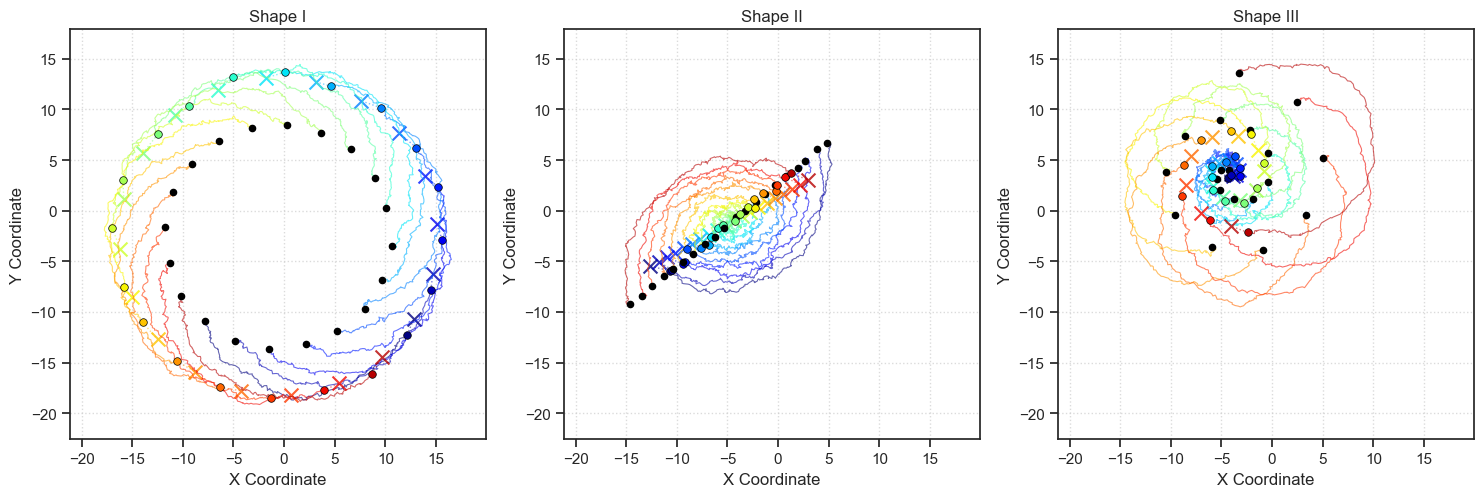

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
import torch
import os
from datetime import datetime
from matplotlib.animation import FuncAnimation
from IPython.display import HTML, display

# --- Simulation Parameters ---
USE_SDE = True              
num_paths = 1000
total_simulation_time = 10.0 

# --- SDE Solver Parameters ---
INTEGRATION_DT = 0.05       

# --- Observation Time Parameters ---
USER_SPECIFIED_OBSERVATION_TIMES = list(np.arange(0, 10.1, 2.0)) # 2s 间隔

current_time_str = datetime.now().strftime("%Y%m%d_%H%M%S")
output_filename_prefix = f"dynamic_tracking_paths_{current_time_str}" # <--- (已修改)

# --- Dynamics Configuration ---
NUM_PARTICLES = 20          # N (状态维度 2N)
LATENT_COND_DIM = 9         # <--- (已修改) 4 cont static + 3 one-hot + 2 cont dynamic

# --- Mean Properties for Conditions ---
INITIAL_NOISE_STD = 0.1   # r0 与 mu(0) 的初始偏差

# 动力学参数 (固定, 非条件)
ALPHA_SPRING = 1.5          # 慢速演化 (使其产生 "延迟")
BETA_REPEL = 0.01           # 弱排斥力
SDE_SIGMA = 0.1

# --- Process Observation Times ---
custom_observation_times = np.sort(np.unique(
    np.clip(np.concatenate(([0], USER_SPECIFIED_OBSERVATION_TIMES, [total_simulation_time])), 0, total_simulation_time)
))
NUM_OBSERVED_TIMEPOINTS = len(custom_observation_times)

# --- Time points for Solver ---
num_fine_plot_steps = int(total_simulation_time * 20) + 1 # 20 FPS
t_eval_fine_plotting = np.linspace(0, total_simulation_time, num_fine_plot_steps)
t_eval_for_solver_REQUESTED = np.sort(np.unique(np.concatenate((t_eval_fine_plotting, custom_observation_times))))
num_solver_eval_points = len(t_eval_for_solver_REQUESTED)


# -----------------------------------------------------------------
# --- (已修改) 形状生成器 g(c, t) -> mu(t) ---
# -----------------------------------------------------------------
def generate_target_shape(latent_c, N, t=0.0):
    """
    根据一个潜在条件 c (9 维) 和时间 t 生成 2N 维的 *瞬时* 目标点 mu(t)。
    c[0], c[1]: 平移 (X, Y)         (连续, 静态)
    c[2]: 基准旋转 (Angle)         (连续, 静态)
    c[3]: 基准缩放 (Scale)           (连续, 静态)
    c[4], c[5], c[6]: 形状 One-Hot   (离散, 静态)
    c[7]: 旋转频率 (omega_rot)    (连续, 动态)
    c[8]: 脉冲频率 (omega_pulse)  (连续, 动态)
    """
    # 1. 解码静态形状
    shape_id = np.argmax(latent_c[4:7]) 
    if shape_id == 0: # 圆环
        angles_circ = np.linspace(0, 2 * np.pi, N, endpoint=False)
        mu_base = np.stack([np.cos(angles_circ), np.sin(angles_circ)], axis=1) * 15.0
    elif shape_id == 1: # 直线
        mu_base = np.stack([np.linspace(-20, 20, N), np.zeros(N)], axis=1)
    else: # 螺线
        angles_spi = np.linspace(0, 4 * np.pi, N) 
        radii_spi = angles_spi * (15.0 / (4 * np.pi)) 
        mu_base = np.stack([radii_spi * np.cos(angles_spi), 
                             radii_spi * np.sin(angles_spi)], axis=1)
    
    # 2. 解码动态参数
    base_scale = 1.0 + 0.5 * np.tanh(latent_c[3])
    base_angle = np.tanh(latent_c[2]) * np.pi
    translation = np.tanh(latent_c[0:2]) * 5.0
    
    omega_rot = np.tanh(latent_c[7]) * 0.5    # 旋转速度 (rad/s)
    omega_pulse = np.tanh(latent_c[8]) * 0.5  # 脉冲速度 (rad/s)
    
    # 3. (*** 核心修改: 应用时变变换 ***)
    
    # 动态缩放 (在 [0.5, 1.5] * base_scale 之间振荡)
    current_scale = base_scale * (1.0 + 0.5 * np.sin(omega_pulse * t))
    mu_scaled = mu_base * current_scale
    
    # 动态旋转 (在 base_angle 基础上叠加)
    current_angle = base_angle + omega_rot * t
    R = np.array([[np.cos(current_angle), -np.sin(current_angle)],
                  [np.sin(current_angle),  np.cos(current_angle)]])
    mu_rotated = mu_scaled @ R.T 
    
    # 动态平移 (保持静态)
    mu_final = mu_rotated + translation
    
    return mu_final # (N, 2) [瞬时目标]


# --- 动力学漂移函数 (*** 已修改 ***) ---
def stable_interacting_drift(t, y_state, N, alpha, beta, latent_c):
    """
    计算非自治 (时变) SDE 的漂移项
    t: 当前时间
    y_state: 扁平的 2N 维 [pos_flat]
    latent_c: 扁平的 9 维 [cond_vec]
    """
    pos = y_state.reshape((N, 2))
    
    # (*** 核心修改: 实时计算 mu(t) ***)
    targets = generate_target_shape(latent_c, N, t=t) 
    
    drift = np.zeros_like(pos)
    
    # (A项) 追踪动态目标
    drift += alpha * (targets - pos)
    
    # (B项) O(N^2) 排斥力 (不变)
    delta_pos = pos[:, np.newaxis, :] - pos[np.newaxis, :, :] 
    dists_sq = np.sum(delta_pos**2, axis=2)
    dists_sq[np.diag_indices(N)] = np.inf 
    dists_cubed = (dists_sq + 1e-6)**1.5 
    force_vecs = beta * (delta_pos / dists_cubed[..., np.newaxis])
    drift += np.sum(force_vecs, axis=1) # B项
    
    return drift.ravel()


# --- Generate Initial Conditions for Each Path ---
# (*** 核心修改: 4 cont + 3 one-hot + 2 dynamic ***)
print("Generating dynamic multi-modal conditions (one-hot)...")
# 4 静态连续
paths_c_static = np.random.randn(num_paths, 4) 
# 3 One-Hot
paths_c_indices = np.random.randint(0, 3, num_paths) 
paths_c_one_hot = np.zeros((num_paths, 3))
paths_c_one_hot[np.arange(num_paths), paths_c_indices] = 1
# 2 动态连续
paths_c_dynamic = np.random.randn(num_paths, 2)
# 最终条件向量 (9 维)
paths_c_shape = np.concatenate((paths_c_static, paths_c_one_hot, paths_c_dynamic), axis=1)


# --- Simulate Paths ---
all_paths_solver_eval_list = [] 
all_paths_conditions_list = []  
t_eval_for_solver_ACTUAL = None 
TOTAL_COND_DIM = LATENT_COND_DIM # (*** 核心修改: 只有 9 ***)

print(f"Simulating {num_paths} paths ({NUM_PARTICLES} tracking particles each, state dim {2*NUM_PARTICLES})...")
print(f"SDE Mode: {USE_SDE}")
print(f"Total Condition Dim: {TOTAL_COND_DIM} (Dynamic Latent Shape Vector)")
print(f"Dynamics: ALPHA={ALPHA_SPRING}, BETA={BETA_REPEL}, SIGMA={SDE_SIGMA}")

successful_simulations = 0
for i in range(num_paths):
    if (i+1) % 100 == 0:
        print(f"Simulating path {i+1}/{num_paths}")
    
    # 1. 获取潜在形状条件
    latent_c = paths_c_shape[i] # (9,)
    
    # 2. (*** 核心修改: 计算 mu(t=0) ***)
    target_points_mu_zero = generate_target_shape(latent_c, NUM_PARTICLES, t=0.0) # (N, 2)
    
    # 3. (*** 核心修改: 生成 r0 作为 mu(0) 的噪声版本 ***)
    r0_array = target_points_mu_zero + np.random.randn(NUM_PARTICLES, 2) * INITIAL_NOISE_STD
    y0 = r0_array.ravel() # (2N,)
    
    # 4. (*** 核心修改: 动力学参数现在是 c ***)
    dyn_args = {
        'N': NUM_PARTICLES,
        'alpha': ALPHA_SPRING,
        'beta': BETA_REPEL,
        'latent_c': latent_c # <--- (SDE现在需要 c 来计算 mu(t))
    }
    sde_sigma = SDE_SIGMA
    
    # 5. (*** 核心修改: 条件向量只有 c ***)
    condition_vector = latent_c
    
    # 6. 求解器
    sol_pos_at_eval_points = None
    sol_success = False
    try:
        if USE_SDE:
            # (*** SDE 求解器已修改 ***)
            dt = INTEGRATION_DT
            num_integration_steps = int(total_simulation_time / dt) + 1
            t_integration_steps = np.linspace(0, total_simulation_time, num_integration_steps)
            eval_indices = np.searchsorted(t_integration_steps, t_eval_for_solver_REQUESTED)
            eval_indices = np.clip(np.unique(eval_indices), 0, num_integration_steps - 1)
            
            if t_eval_for_solver_ACTUAL is None:
                t_eval_for_solver_ACTUAL = t_integration_steps[eval_indices]
                num_solver_eval_points = len(t_eval_for_solver_ACTUAL)
            
            y_all_steps = np.zeros((num_integration_steps, 2 * NUM_PARTICLES))
            y_all_steps[0] = y0
            dW_all = np.random.randn(num_integration_steps - 1, 2 * NUM_PARTICLES) * np.sqrt(dt)
            
            for k in range(num_integration_steps - 1):
                y_current = y_all_steps[k] 
                t_current = t_integration_steps[k]
                # (*** 漂移函数现在接收 t 和 c ***)
                drift = stable_interacting_drift(t_current, y_current, **dyn_args) * dt
                diffusion = np.sqrt(2 * sde_sigma) * dW_all[k]
                y_all_steps[k+1] = y_current + drift + diffusion
            
            sol_pos_at_eval_points = y_all_steps[eval_indices, :]
            sol_success = True
        else:
            # (*** ODE 求解器已修改 ***)
            if t_eval_for_solver_ACTUAL is None:
                t_eval_for_solver_ACTUAL = t_eval_for_solver_REQUESTED
            sol = solve_ivp(
                stable_interacting_drift, # <--- (函数签名现在与 t 兼容)
                [0, total_simulation_time], 
                y0,
                args=tuple(dyn_args.values()), # (传递 alpha, beta, c)
                dense_output=False,
                t_eval=t_eval_for_solver_ACTUAL, 
                method='RK45', 
                rtol=1e-5, atol=1e-5
            )
            if sol.success and sol.y.shape[1] == num_solver_eval_points:
                sol_pos_at_eval_points = sol.y.T 
                sol_success = True
            else:
                print(f"Warning: Path {i} ODE solve failed.")
    
    except Exception as e:
        print(f"Error simulating path {i}: {e}")
        sol_success = False

    # 7. 存储结果
    if sol_success and sol_pos_at_eval_points.shape[0] == num_solver_eval_points:
        all_paths_solver_eval_list.append(sol_pos_at_eval_points)
        all_paths_conditions_list.append(condition_vector) # (保存 9-dim c)
        successful_simulations += 1
    else:
        nan_path = np.full((num_solver_eval_points, 2*NUM_PARTICLES), np.nan) 
        all_paths_solver_eval_list.append(nan_path)
        nan_condition = np.full(condition_vector.shape, np.nan)
        all_paths_conditions_list.append(nan_condition)

# --- Filter failed paths ---
all_paths_solver_eval = np.array(all_paths_solver_eval_list)
all_paths_conditions = np.array(all_paths_conditions_list)
print(f"Simulation complete. {successful_simulations}/{num_paths} paths successfully integrated.")
if successful_simulations == 0:
    print("Error: No paths were successfully simulated. Exiting.")
    exit()
valid_paths_mask = ~np.all(np.isnan(all_paths_solver_eval), axis=(1,2))
all_paths_solver_eval_filtered = all_paths_solver_eval[valid_paths_mask]
all_paths_conditions_filtered = all_paths_conditions[valid_paths_mask]
if all_paths_solver_eval_filtered.shape[0] == 0:
    print("Error: No valid paths after filtering. Exiting.")
    exit()
num_valid_paths = all_paths_solver_eval_filtered.shape[0]
print(f"{num_valid_paths} valid paths will be used for analysis.")

# --- Extract Observed Data ---
observation_point_indices = np.where(np.isclose(t_eval_for_solver_ACTUAL, custom_observation_times[:, None], atol=1e-6))[1]
observation_point_indices = np.unique(observation_point_indices)
observed_paths_data = all_paths_solver_eval_filtered[:, observation_point_indices, :]
actual_sparse_times = t_eval_for_solver_ACTUAL[observation_point_indices]
NUM_OBSERVED_TIMEPOINTS = len(actual_sparse_times)

# --- Save as PyTorch Tensors ---
if observed_paths_data.shape[0] > 0:
    sparse_trajectories_tensor = torch.tensor(observed_paths_data, dtype=torch.float32)
    dense_trajectories_tensor = torch.tensor(all_paths_solver_eval_filtered, dtype=torch.float32)
    conditions_tensor = torch.tensor(all_paths_conditions_filtered, dtype=torch.float32) # (B, 9)
    print("\n--- Generated PyTorch Tensors ---")
    print(f"Sparse Trajectories Tensor Shape (for Train):   {sparse_trajectories_tensor.shape}")
    print(f"Dense Trajectories Tensor Shape (for Val/Test): {dense_trajectories_tensor.shape}")
    print(f"Conditions Tensor Shape (Shared):               {conditions_tensor.shape}") 
    split_idx = int(num_valid_paths * 0.7)
    train_data = {
        'trajectories': sparse_trajectories_tensor[:split_idx],
        'conditions': conditions_tensor[:split_idx],
        'observation_times': torch.tensor(actual_sparse_times, dtype=torch.float32)
    }
    val_data = {
        'trajectories': dense_trajectories_tensor[split_idx:],
        'conditions': conditions_tensor[split_idx:],
        'observation_times': torch.tensor(t_eval_for_solver_ACTUAL, dtype=torch.float32)
    }
    output_dir = f"simulated_data_{current_time_str}"
    os.makedirs(output_dir, exist_ok=True)
    save_path = os.path.join(output_dir, f"{output_filename_prefix}_conditional_data.pt")
    torch.save({'train': train_data, 'val': val_data}, save_path)
    print(f"\nSimulated trajectories and conditions saved to {save_path}")
    print(f"Training set: {split_idx} paths (Sparse: {NUM_OBSERVED_TIMEPOINTS} points)")
    print(f"Validation set: {num_valid_paths - split_idx} paths (Dense: {num_solver_eval_points} points)")
else:
    print("No valid data to save after filtering.")

# -----------------------------------------------------------------
# --- 可视化 --- (*** 已修改以处理动态 mu(t) ***)
# -----------------------------------------------------------------

def plot_multiple_paths(list_of_path_data, list_of_latent_conditions, N, N_rows, N_cols, titles):
    import seaborn as sns
    sns.set_theme(style="ticks")
    num_simulations = len(list_of_path_data)
    if num_simulations != len(titles) or num_simulations != len(list_of_latent_conditions):
        raise ValueError("list_of_path_data, conditions 和 titles 的长度必须一致。")
        
    g_x_min, g_y_min = np.inf, np.inf
    g_x_max, g_y_max = -np.inf, -np.inf
    all_mu_final_targets = [] # 存储 *最终* 目标点

    for path_data, cond_c in zip(list_of_path_data, list_of_latent_conditions):
        # 1. 检查轨迹
        num_steps = path_data.shape[0]
        path_data_reshaped = path_data.reshape(num_steps, N, 2)
        x_min, y_min = np.min(path_data_reshaped, axis=(0, 1))
        x_max, y_max = np.max(path_data_reshaped, axis=(0, 1))
        
        # 2. (*** 已修改 ***) 从 c 生成 mu(t=0) 和 mu(t=T)
        mu_t0 = generate_target_shape(cond_c, N, t=0.0)
        mu_tT = generate_target_shape(cond_c, N, t=total_simulation_time)
        all_mu_final_targets.append(mu_tT) # 只存储最终目标
        
        # 3. 检查边界 (包括 t0 和 tT 的目标)
        mu_x_min, mu_y_min = np.min(np.concatenate([mu_t0, mu_tT]), axis=0)
        mu_x_max, mu_y_max = np.max(np.concatenate([mu_t0, mu_tT]), axis=0)
        g_x_min = min(g_x_min, x_min, mu_x_min)
        g_y_min = min(g_y_min, y_min, mu_y_min)
        g_x_max = max(g_x_max, x_max, mu_x_max)
        g_y_max = max(g_y_max, y_max, mu_y_max)
        
    padding = max(g_x_max - g_x_min, g_y_max - g_y_min) * 0.1
    g_x_min -= padding; g_x_max += padding; g_y_min -= padding; g_y_max += padding

    fig, axes = plt.subplots(N_rows, N_cols, figsize=(5 * N_cols, 5 * N_rows), squeeze=False)
    axes_flat = axes.flatten()
    cmap = plt.cm.jet
    
    for idx in range(num_simulations):
        if idx >= N_rows * N_cols: break 
        ax = axes_flat[idx]
        title = titles[idx]
        path_data = list_of_path_data[idx]
        mu_final_targets = all_mu_final_targets[idx] 
        num_steps = path_data.shape[0]
        path_data_reshaped = path_data.reshape(num_steps, N, 2)
        ax.set_xlim(g_x_min, g_x_max)
        ax.set_ylim(g_y_min, g_y_max)
        
        for i in range(N):
            particle_path = path_data_reshaped[:, i, :]
            target_pos = mu_final_targets[i, :]
            color = cmap(i/N)
            
            # 1. 绘制 *最终* 目标点 (大 'X')
            ax.scatter(target_pos[0], target_pos[1], color=color, marker='x', s=100, zorder=2, alpha=0.8)
            # 2. 绘制轨迹线
            ax.plot(particle_path[:, 0], particle_path[:, 1], c=color, alpha=0.6, lw=0.8)
            # 3. 绘制起点 (黑色圆圈)
            ax.scatter(particle_path[0, 0], particle_path[0, 1], c='black', marker='o', s=20, zorder=3)
            # 4. 绘制终点 (彩色实心圆)
            ax.scatter(particle_path[-1, 0], particle_path[-1, 1], color=color, marker='o', s=30, zorder=3, edgecolors='black', linewidth=0.5)
            # 5. (可选) 绘制从终点到最终目标的虚线
            ax.plot([particle_path[-1, 0], target_pos[0]], 
                    [particle_path[-1, 1], target_pos[1]], 
                    c=color, ls=':', lw=1, alpha=0.5)
            
        ax.set_title(title, fontsize=12)
        ax.set_xlabel('X Coordinate')
        ax.set_ylabel('Y Coordinate')
        ax.grid(True, linestyle=':', alpha=0.7)
        ax.set_aspect('equal')
        
    for i in range(num_simulations, N_rows * N_cols):
        fig.delaxes(axes_flat[i])
    fig.tight_layout()
    plt.savefig('SWARM_DATA.pdf', format='pdf', bbox_inches='tight')
    plt.show()

def animate_single_path(path_data, latent_cond_data, time_points, N, title):
    """
    动画: (*** 已修改 ***)
    - 粒子 (实心圆) 追踪
    - 动态目标 ( 'X' 标记)
    """
    num_steps = path_data.shape[0]
    path_data_reshaped = path_data.reshape(num_steps, N, 2)
    
    # (*** 核心修改: 计算 *所有* 目标点 ***)
    mu_trajectory = np.array([generate_target_shape(latent_cond_data, N, t) for t in time_points])
    
    fig_anim, ax_anim = plt.subplots(figsize=(10, 10))
    
    # 动态确定边界 (基于粒子 *和* 目标轨迹)
    all_points_for_bounds = np.concatenate([path_data_reshaped, mu_trajectory])
    x_min, y_min = np.min(all_points_for_bounds, axis=(0, 1))
    x_max, y_max = np.max(all_points_for_bounds, axis=(0, 1))
    
    padding = max(x_max - x_min, y_max - y_min) * 0.1
    ax_anim.set_xlim(x_min - padding, x_max + padding)
    ax_anim.set_ylim(y_min - padding, y_max + padding)
    
    ax_anim.set_title(title, fontsize=16)
    ax_anim.set_xlabel('X Coordinate', fontsize=12)
    ax_anim.set_ylabel('Y Coordinate', fontsize=12)
    ax_anim.set_aspect('equal')
    
    colors = plt.cm.jet(np.linspace(0, 1, N))
    
    # (*** 核心修改: 'targets_scatter' 现在也是动画的一部分 ***)
    # 初始化 "幽灵" 目标
    targets_scatter = ax_anim.scatter(
        mu_trajectory[0, :, 0], mu_trajectory[0, :, 1], 
        c=colors, marker='x', s=150, alpha=0.8, zorder=2
    )
    # 初始化 "真实" 粒子
    particles_scatter = ax_anim.scatter(
        path_data_reshaped[0, :, 0], path_data_reshaped[0, :, 1], 
        s=40, c=colors, zorder=3, edgecolors='black', linewidth=0.5
    )
    
    time_text = ax_anim.text(0.02, 0.95, '', transform=ax_anim.transAxes, fontsize=12,
                             bbox=dict(facecolor='white', alpha=0.7))
    
    def update(frame):
        # 1. 更新 "真实" 粒子
        current_pos = path_data_reshaped[frame]
        particles_scatter.set_offsets(current_pos)
        
        # 2. (*** 核心修改: 更新 "幽灵" 目标 ***)
        current_targets = mu_trajectory[frame]
        targets_scatter.set_offsets(current_targets)
        
        current_time = time_points[frame]
        time_text.set_text(f'Time: {current_time:.2f} s')
        return particles_scatter, targets_scatter, time_text # (*** 已修改 ***)
    
    target_duration_sec = 15
    target_fps = 30
    total_frames_target = target_duration_sec * target_fps
    
    if num_steps <= total_frames_target:
        frame_indices = np.arange(num_steps)
    else:
        frame_indices = np.linspace(0, num_steps - 1, total_frames_target, dtype=int)
        
    anim = FuncAnimation(fig_anim, update, frames=frame_indices,
                         interval=max(20, 1000 // target_fps), blit=True, repeat=True)
    
    plt.close(fig_anim)
    return anim

# --- 调用可视化 ---
if num_valid_paths > 0:
    # 1. 定义寻找的目标形状索引
    target_shape_indices = [4, 5, 6]  # 对应 c[4], c[5], c[6]
    shape_labels = ["Shape I", "Shape II", "Shape III"] 

    # ==========================================
    # 2. 定义可视化筛选阈值 (可根据需要调整)
    # ==========================================
    # 旋转角度 (c[2]): 绝对值至少要大于 0.5 (约30度)，避免看起来像没转
    MIN_ROT_ABS = 0.5 
    # 缩放比例 (c[3]): 绝对值至少要大于 0.8 (避免物体太小看不清细节)
    # 注意：如果你的 Scale 范围本身就在 [0.5, 1.5] 之间，这个值设为 0.7 或 0.8 比较合适
    MIN_SCALE_ABS = 0.1 

    selected_indices = []
    selected_titles_temp = []

    # 3. 遍历每一个目标形状，找到符合“形状+幅值”要求的样本
    for target_idx, label in zip(target_shape_indices, shape_labels):
        found = False
        for i, cond in enumerate(all_paths_conditions_filtered):
            
            # 获取当前样本的条件值
            rot_val = cond[2]
            scale_val = cond[3]
            
            # 筛选条件：
            # (1) 是当前目标形状 (One-Hot == 1)
            # (2) 之前没被选过
            # (3) 旋转角度绝对值足够大 (abs(rot) > threshold)
            # (4) 缩放比例绝对值足够大 (abs(scale) > threshold)
            if (cond[target_idx] == 1.0 and 
                i not in selected_indices and 
                abs(rot_val) > MIN_ROT_ABS and 
                abs(scale_val) > MIN_SCALE_ABS):
                
                selected_indices.append(i)
                
                # 生成标题 (包含具体的旋转和缩放值，方便确认筛选结果)
                omega_rot = cond[7]
                omega_pulse = cond[8]
                
                # 标题格式：形状 + 静态参数(R, S) + 动态参数(w_rot, w_pulse)
                # 为了排版整洁，这里只显示动态参数，或者你可以把 R/S 也加上
                title_str = (f"{label}\n"
                            f"R={rot_val:.1f}, S={scale_val:.1f}\n"
                            f"$\\omega_{{r}}={omega_rot:.1f}, \\omega_{{p}}={omega_pulse:.1f}$")
                selected_titles_temp.append(label)
                
                found = True
                break # 找到符合要求的一个后，跳出，去选下一个形状
        
        if not found:
            # 如果加了阈值导致找不到样本，建议打印出来提示，或者在下一轮循环放宽条件
            print(f"Warning: No sample found for shape index {target_idx} with current thresholds.")

    # 4. 构建最终变量 (保持原有变量名，直接对接绘图函数)
    num_plots_to_show = len(selected_indices)
    path_data_for_multiplot = [all_paths_solver_eval_filtered[i] for i in selected_indices]
    cond_data_for_multiplot = [all_paths_conditions_filtered[i] for i in selected_indices]
    titles_for_multiplot = selected_titles_temp
        
    plot_multiple_paths(
        list_of_path_data=path_data_for_multiplot,
        list_of_latent_conditions=cond_data_for_multiplot, 
        N=NUM_PARTICLES,
        N_rows=1, N_cols=3,
        titles=titles_for_multiplot
    )
    
    # print("Preparing animation (this may take a moment)...")
    # animation_object = animate_single_path(
    #     path_data=all_paths_solver_eval_filtered[0],    
    #     latent_cond_data=all_paths_conditions_filtered[0], 
    #     time_points=t_eval_for_solver_ACTUAL,           
    #     N=NUM_PARTICLES,
    #     title=f"Animated Dynamic Tracking (N={NUM_PARTICLES}, SDE={USE_SDE})" # <--- (已修改)
    # )
    
    # display(HTML(animation_object.to_html5_video()))
else:
    print("No valid data to visualize.")

In [3]:
import torch
import torch.nn.functional as F
import os
import numpy as np
import pandas as pd
import sklearn
import matplotlib.pyplot as plt

import cubic_SI
from cubic_SI import model
from cubic_SI import computations as cmp

Successfully imported configured torchcubicspline.


In [4]:
import random
def setup_seed(seed: int = 42, deterministic: bool = False):
    """
    统一设置 PyTorch/NumPy/Random 的随机种子
    @param seed: 基础随机种子（建议 0-2^32-1 之间）
    @param deterministic: 是否开启严格确定性模式（可能影响 GPU 性能）
    """
    # Python 内置随机数
    random.seed(seed)
    
    # NumPy 随机性
    np.random.seed(seed)
    
    # PyTorch CPU 随机性
    torch.manual_seed(seed)
    
    # PyTorch GPU 随机性（单卡+多卡）
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)  # 多卡情况
    
    # 确定性优化（需谨慎！可能降低 GPU 速度）
    if deterministic:
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False
        torch.backends.cudnn.enabled = False  # 如需使用 cudnn，建议仅设置 deterministic=True
        
setup_seed(seed=42)

In [5]:
SI_class = model.Cubic_SI_model(train_data['trajectories'], USER_SPECIFIED_OBSERVATION_TIMES,condition_tensor=train_data['conditions'],
                                n_layers=4,hiden_size=94,
                                N_training=10000, B=128, model_lr=1e-3,steps=20*total_simulation_time,
                                func_type='sqrt',
                                u_t=lambda x: SDE_SIGMA,
                                spline=True,
                                save_path='model_history/flocking_spline',record_gap=10
                                )

71950
71950


processed: 10000: 100%|██████████| 10000/10000 [09:37<00:00, 17.31it/s, loss=6.5050716, loss_b=3.7383158, loss_k=2.7667563]


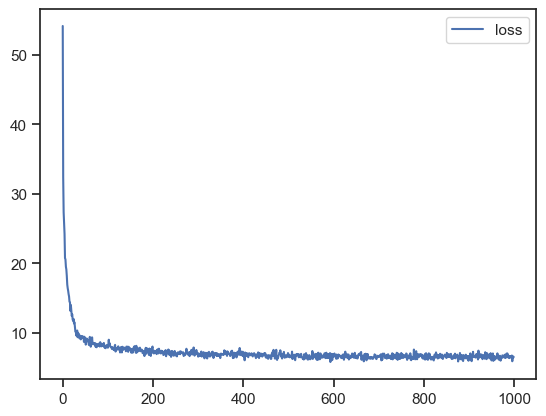

In [6]:
SI_class.train()

In [7]:
generated_paths_ODE = SI_class.eval(val_data['trajectories'][:,0,:],conditions=val_data['conditions'],SDE=True)
generated_paths_ODE = torch.stack(generated_paths_ODE).transpose(0,1)
generated_paths_ODE_spline = generated_paths_ODE

71950
71950


processed: 10000: 100%|██████████| 10000/10000 [10:36<00:00, 15.71it/s, loss=6.7897987, loss_b=4.606361, loss_k=2.1834383]


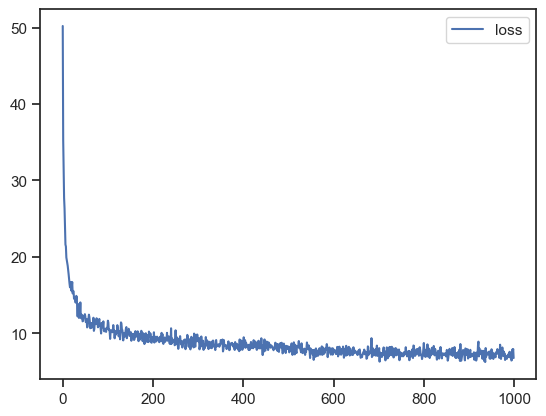

In [8]:
SI_class = model.Cubic_SI_model(train_data['trajectories'], USER_SPECIFIED_OBSERVATION_TIMES,condition_tensor=train_data['conditions'],
                                n_layers=4,hiden_size=94,
                                N_training=10000, B=128, model_lr=1e-3,steps=20*total_simulation_time,
                                func_type='sqrt',
                                u_t=lambda x: SDE_SIGMA,
                                spline=False,
                                save_path='model_history/flocking_linear',record_gap=10
                                )
SI_class.train()
generated_paths_ODE = SI_class.eval(val_data['trajectories'][:,0,:],conditions=val_data['conditions'],SDE=True)
generated_paths_ODE = torch.stack(generated_paths_ODE).transpose(0,1)
generated_paths_ODE_linear = generated_paths_ODE

--- 警告: 正在删除陈旧的缓存目录: flocking_experiment_results\model_batch_cache_Flocking_Sim ---
Starting evaluation for: Flocking_Sim
Using device: cuda


NOTE: 'generated_paths_ODE_linear' or 'SSCI' not found.
Running evaluation for *baselines only*.

--- Loading data from simulated_data_20260121_233240\dynamic_tracking_paths_20260121_233240_conditional_data.pt ---
   Data Dim (2N): 40
   Cond Dim (9): 9
Creating data bundle...
   Training samples: 700
   Validation samples: 300
   Sparse times (S_train): 6
   Dense times (T_val): 201
   Generation times (T_gen): 201
   Raw data cleared from memory.

       Phase 1 & 2: Sequential Training & Generation       
       Batch Cache Dir: flocking_experiment_results\model_batch_cache_Flocking_Sim       
       Manifest File:   flocking_experiment_results\baseline_manifest_Flocking_Sim.pt       

   (Phase 1a) Caching ground truth paths to manifest...


   Caching Truth: 100%|██████████| 3/3 [00:00<00:00, 600.10it/s]


   Ground truth manifest saved to flocking_experiment_results\baseline_manifest_Flocking_Sim.pt

--- Processing Model: LatentODEVaE ---
       Model: LatentODEVaE, Trainable Parameters: 146,088


     Epoch 10000/10000 | ELBO: 0.6477 (R: 0.5872, KL: 6.0511): 100%|██████████| 10000/10000 [1:21:37<00:00,  2.04it/s]



       Training complete. Time elapsed: 4897.05s
       Generating batches to flocking_experiment_results\model_batch_cache_Flocking_Sim\LatentODEVaE...


...

       'LatentODEVaE' assembled. Shape: torch.Size([300, 201, 40])
       Successfully assembled 2 baseline models.

   --- Loading 2 extra models... ---
       'CSI' T=201 matches T_val=201.
       Successfully loaded and added 'CSI' from flocking_experiment_results\my_csi_paths.pt
       'SSCI' T=201 matches T_val=201.
       Successfully loaded and added 'SSCI' from flocking_experiment_results\my_gsci_paths.pt
       Will evaluate a total of 4 models.

   --- Creating shared color map ('deep') ---
       Model order and color assignment (for legends):
       SSCI                      (Extra)    -> Color: {'color': '#D9363E', 'lw': 2.0, 'linestyle': '-', 'zorder': 100, 'alpha': 1.0, 'label': 'SSCI (Ours)'}
       CSI                       (Extra)    -> Color: {'color': '#2E5EAA', 'lw': 2.0, 'linestyle': '--', 'zorder': 90, 'alpha': 1.0, 'label': 'CSI'}
       LatentODEVaE              (Baseline) -> Color: {'color': '#56A36C', 'lw': 2.0, 'linestyle': '--', 'zorder': 10, 'alpha': 1.0, 

       Processing model: LatentODEVaE (Shape: torch.Size([300, 201, 40]))
       Calculating time-step metrics (using Sinkhorn)...


       Processing model: CSI (Shape: torch.Size([300, 201, 40]))
       Calculating time-step metrics (using Sinkhorn)...


       Processing model: SSCI (Shape: torch.Size([300, 201, 40]))
       Calculating time-step metrics (using Sinkhorn)...



--- 正在生成 MSE 指标图 ---
   [Plot] Mean Squared Error (MSE): 未检测到显著性能差距。显示合并图表。


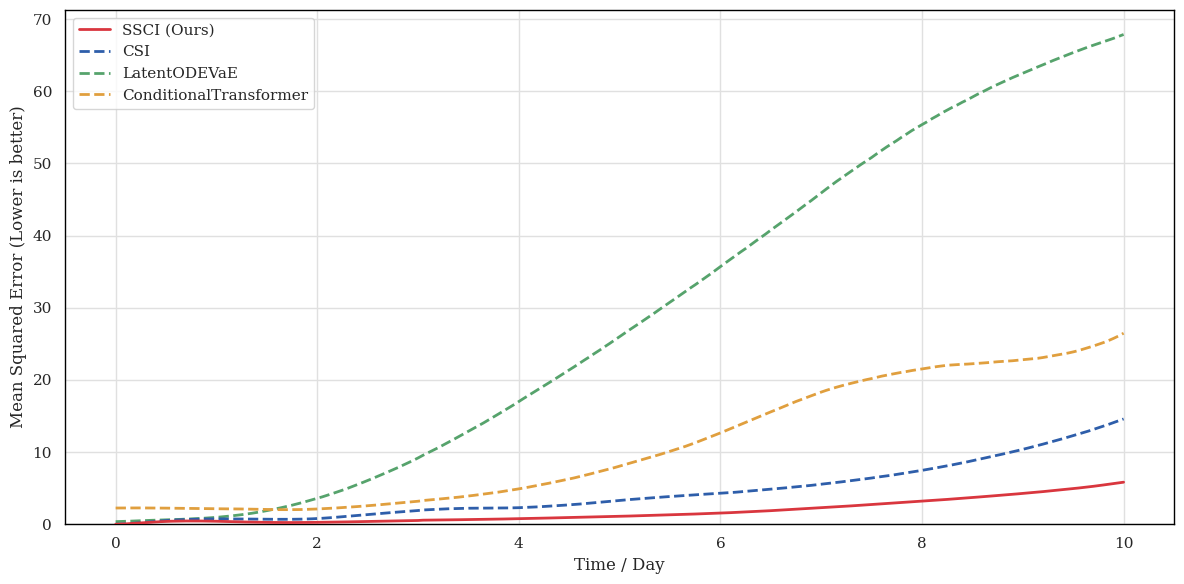


--- 正在生成 Wasserstein 指标图 ---
   [Plot] Wasserstein Distance: 未检测到显著性能差距。显示合并图表。


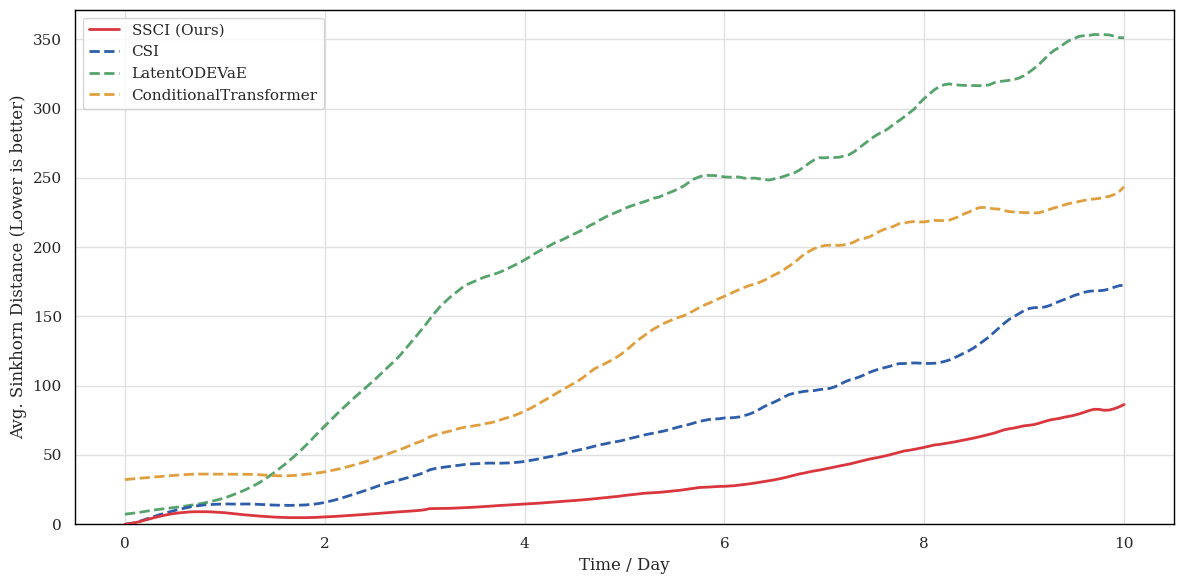


   --- Starting Path Visualization (Flocking Plot) ---
tensor(1)
tensor(2)
tensor(1)
tensor(0)
tensor(1)
tensor(2)
tensor(2)
tensor(0)
tensor(1)
tensor(2)
tensor(1)
tensor(1)
tensor(2)
tensor(1)
tensor(0)
tensor(1)
tensor(2)
Processing Sample 3 for FLOCKING_SIM...
Saving individual static plots...
  -> Saved SWARM_GEN0_GroundTruth.pdf
  -> Saved SWARM_GEN0_ConditionalTransformer.pdf
  -> Saved SWARM_GEN0_LatentODEVaE.pdf
  -> Saved SWARM_GEN0_CSI.pdf
  -> Saved SWARM_GEN0_SSCI.pdf
Generating animation (preview)...
Animation saved to FLOCKING_SIM_Sample0.mp4
Processing Sample 7 for FLOCKING_SIM...
Saving individual static plots...
  -> Saved SWARM_GEN1_GroundTruth.pdf
  -> Saved SWARM_GEN1_ConditionalTransformer.pdf
  -> Saved SWARM_GEN1_LatentODEVaE.pdf
  -> Saved SWARM_GEN1_CSI.pdf
  -> Saved SWARM_GEN1_SSCI.pdf
Generating animation (preview)...
Animation saved to FLOCKING_SIM_Sample1.mp4
Processing Sample 0 for FLOCKING_SIM...
Saving individual static plots...
  -> Saved SWARM_GEN2_

In [10]:
#!/usr/bin/env python
# -*- coding: utf-8 -*-

import warnings
from linear_operator.utils.warnings import NumericalWarning

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from geomloss import SamplesLoss # Make sure to pip install geomloss
import numpy as np
import time
from scipy.stats import wasserstein_distance
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm # <-- 确保 tqdm 已导入
import os
from pathlib import Path
import matplotlib.patches as mpatches
import torch.nn.functional as F # <-- 确保 F 已导入
import matplotlib.cm as cm # <-- 为新的绘图函数导入
import gc # <-- 导入垃圾回收模块

# ==============================================================================
# 0. Dependencies Check
# ==============================================================================
try: 
    from torchdiffeq import odeint
except ImportError:
    raise ImportError("Please install torchdiffeq: pip install torchdiffeq")
try:
    import torchsde
except ImportError:
    raise ImportError("Please install torchsde: pip install torchsde")
try:
    import gpytorch
    from gpytorch.likelihoods import GaussianLikelihood
    from gpytorch.means import ConstantMean
    from gpytorch.kernels import ScaleKernel, RBFKernel
    from gpytorch.distributions import MultivariateNormal
except ImportError:
    raise ImportError("Please install gpytorch: pip install gpytorch")

# ==============================================================================
# 1. Experiment, Data, and Model Configuration
# ==============================================================================

# Experiment Config: 将在 main 模块中动态填充
EXPERIMENT_CONFIG = {
    "DEVICE": "cuda" if torch.cuda.is_available() else "cpu",
    "DATA_DIM": None, # 将从加载的数据中设置
    "COND_DIM": None, # 将从加载的数据中设置
    "BATCH_SIZE": 128,
}


# Model Config: (*** 已修改 ***) 激活了所有基线
MODEL_CONFIG = {
    # <<< 提醒: 您将Epochs设为1用于测试。
    # <<< 在实际运行中, 请确保将它们设置回 2048 或更高。
    "LatentODEVaE": {
        "latent_dim": 128,         # 潜空间维度
        "vae_hidden_dim": 128,     # VAE 编码器/解码器的隐藏维度
        "dyn_hidden_dim": 128,     # 动力学网络(f)的隐藏维度
        "kl_weight": 0.01,
        "epochs": 10000, 
        "lr": 1e-3
    },
    
    "LatentSDEVaE": {
        "latent_dim": 128,         # 潜空间维度
        "vae_hidden_dim": 128,     # VAE 编码器/解码器的隐藏维度
        "dyn_hidden_dim": 128,     # 动力学网络(f)的隐藏维度
        "diffusion_hyperparam": 0.1, # SDE 的 g(t,z) 超参数
        "kl_weight": 0.01,
        "epochs": 10000,
        "lr": 1e-3
    },
    "ConditionalTransformer": {
        "embed_dim": 32,
        "nhead": 4, 
        "num_layers": 1, 
        "epochs": 10000, 
        "lr": 1e-3
    },
    # "ConditionalGP": {
    #     "optim_steps": 1, # <<< 设回 2048
    #     "lr": 0.1
    # },
}



STYLE_CONFIG = {
    # --- 核心方法 (Our Method) ---
    "SSCI": {
        "color": "#D9363E",  # [Pyro] 绯红 (Klee Red) - 醒目但不刺眼
        "lw": 2.0,           # 线条最粗
        "linestyle": "-",    # 实线
        "zorder": 100,       # 永远在最顶层 (防止被遮挡)
        "alpha": 1.0,        # 不透明
        "label": "SSCI (Ours)"
    },
    
    # --- 主要对比方法 (Strong Baseline) ---
    "CSI": {
        "color": "#2E5EAA",  # [Hydro] 深宝石蓝 (Eula Blue) - 沉稳
        "lw": 2.0,           # 线条次粗
        "linestyle": "--",    # 实线
        "zorder": 90,        # 仅次于 SSCI
        "alpha": 1.0,
        "label": "CSI"
    },

    # --- 神经网络基线 (Neural Baselines) ---
    "LatentODEVaE": {       # 注意：匹配您代码中的键名(含空格)
        "color": "#56A36C",  # [Dendro] 草神绿 (Nahida Green) - 清新
        "lw": 2.0,           # 标准线宽
        "linestyle": "--",   # 虚线 (区分于 Ours)
        "zorder": 10,        # 后景
        "alpha": 1.0,
        "label": "LatentODEVaE"
    },
    
    # "LatentSDEVaE": {
    #     "color": "#7E57C2",  # [Electro] 雷电紫 (Raiden Purple) - 优雅
    #     "lw": 1.5,
    #     "linestyle": "--",
    #     "zorder": 10,
    #     "alpha": 1.0,
    #     "label": "LatentSDEVaE"
    # },
    
    "ConditionalTransformer": {
        "color": "#E09F3E",  # [Geo] 岩金 (Zhongli Amber) - 明亮
        "lw": 2.0,
        "linestyle": "--",   # 点划线 (增加区分度)
        "zorder": 10,
        "alpha": 1.0,
        "label": "ConditionalTransformer"
    },

    # --- 传统/非参基线 (Traditional/Non-Parametric) ---
    "GaussianProcess": {
        "color": "#7E57C2",  # [Electro] 雷电紫 (Raiden Purple) - 优雅 "#26A69A",  # [Anemo] 魈青 (Xiao Teal) - 高级灰调
        "lw": 2.0,
        "linestyle": "--",    # 点线 (表示非参的不确定性或不同性质)
        "zorder": 5,         # 最底层
        "alpha": 1.0,
        "label": "GaussianProcess"
    }
}


# ==============================================================================
# 2. Baseline Model Definitions
# ==============================================================================


# --- Model 4: Conditional Transformer (不变) ---
class ConditionalTransformer(nn.Module):
    def __init__(self, data_dim, cond_dim, embed_dim=64, nhead=4, num_layers=2, **kwargs):
        super().__init__()
        self.time_encoder = nn.Linear(1, embed_dim)
        self.input_proj = nn.Linear(data_dim, embed_dim)
        self.cond_proj = nn.Linear(cond_dim, embed_dim)
        
        encoder_layer = nn.TransformerEncoderLayer(d_model=embed_dim, nhead=nhead, batch_first=True)
        self.transformer_encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        self.output_proj = nn.Linear(embed_dim, data_dim)

    def forward(self, sparse_data, sparse_times, condition):
        seq_len = sparse_times.shape[1] 
        x0 = sparse_data[:, 0, :].unsqueeze(1).repeat(1, seq_len, 1) 
        time_embed = torch.sin(self.time_encoder(sparse_times.unsqueeze(-1).to(x0.dtype))) 
        data_embed = self.input_proj(x0) 
        cond_embed = self.cond_proj(condition).unsqueeze(1) 
        full_embedding = data_embed + time_embed + cond_embed
        output = self.transformer_encoder(full_embedding)
        return self.output_proj(output)

    def generate(self, x0, t_eval, condition):
        batch_size = x0.shape[0]
        seq_len = len(t_eval) 
        dummy_data = x0.unsqueeze(1).repeat(1, seq_len, 1)
        t_eval_batch = t_eval.unsqueeze(0).repeat(batch_size, 1).to(x0.device, dtype=x0.dtype) 
        return self.forward(dummy_data, t_eval_batch, condition)

# --- Model 5: Conditional Gaussian Process (不变, 除了 .train 中的进度条) ---
class ExactGPModel(gpytorch.models.ExactGP):
    def __init__(self, train_x, train_y, likelihood, cond_dim):
        super().__init__(train_x, train_y, likelihood)
        self.mean_module = ConstantMean()
        self.covar_module = ScaleKernel(RBFKernel(ard_num_dims=1 + cond_dim))
    def forward(self, x):
        mean_x = self.mean_module(x); covar_x = self.covar_module(x)
        return MultivariateNormal(mean_x, covar_x)

class ConditionalGP:
    def __init__(self, data_dim, cond_dim, device, optim_steps=50, lr=0.1, **kwargs):
        self.data_dim, self.cond_dim, self.device = data_dim, cond_dim, device
        self.models, self.likelihoods = [None] * data_dim, [None] * data_dim
        self.optim_steps = optim_steps; self.lr = lr

    def to_device(self, device):
        """将所有内部模型和似然移动到指定设备"""
        self.device = device
        for i in range(self.data_dim):
            if self.models[i]:
                self.models[i] = self.models[i].to(device)
            if self.likelihoods[i]:
                self.likelihoods[i] = self.likelihoods[i].to(device)
        return self

    def to_cpu(self):
        """将所有内部模型和似然移动到 CPU"""
        return self.to_device('cpu')

    def train(self, sparse_obs, sparse_times, conditions):
        print(f"       Optimizing GaussianProcess hyperparameters ({self.optim_steps} steps, lr={self.lr})...")
        num_samples = conditions.shape[0]; num_sparse_obs = sparse_obs.shape[1]
        train_x = sparse_times.float().unsqueeze(0).repeat(num_samples, 1).view(-1, 1).to(self.device)
        train_c = conditions.float().unsqueeze(1).repeat(1, num_sparse_obs, 1).view(-1, self.cond_dim).to(self.device)
        train_x_cond = torch.cat([train_x, train_c], dim=-1).to(self.device)
        
        if self.data_dim > 10:
             print(f"       [Warning] GP data_dim is {self.data_dim}. Training will be very slow.")
        
        with warnings.catch_warnings():
            warnings.filterwarnings(
                'ignore', 
                message="CG terminated in", 
                category=NumericalWarning, 
                module="linear_operator.utils.linear_cg"
            )
            
            with gpytorch.settings.max_cg_iterations(2000):
                
                # <<< 更改: TQDM 嵌套级别调整 (leave=False)
                dim_pbar = tqdm(range(self.data_dim), desc="     GP Dimensions", leave=False)
                
                for i in dim_pbar:
                    train_y = sparse_obs[:, :, i].reshape(-1).to(self.device)
                    likelihood = GaussianLikelihood().to(self.device)
                    model = ExactGPModel(train_x_cond, train_y.float(), likelihood, self.cond_dim).to(self.device) 
                    model.train(); likelihood.train()
                    optimizer = torch.optim.Adam(model.parameters(), lr=self.lr)
                    mll = gpytorch.mlls.ExactMarginalLogLikelihood(likelihood, model)
                    
                    final_loss = 0.0
                    for step in range(self.optim_steps): 
                        optimizer.zero_grad(); output = model(train_x_cond)
                        loss = -mll(output, train_y); loss.backward(); optimizer.step()
                        
                        if step == self.optim_steps - 1:
                            final_loss = loss.item()
                    
                    model.eval(); likelihood.eval()
                    self.models[i], self.likelihoods[i] = model, likelihood
                    
                    dim_pbar.set_description(f"     GP Dim {i+1}/{self.data_dim} (Loss: {final_loss:.2f})")
        
        print("       GaussianProcess hyperparameter optimization complete.")


    def generate(self, x0, t_eval, condition):
        """
        <<< MODIFIED: 
        在此函数内部实现子批处理 (sub-batching) 以防止 OOM。
        它现在一次处理批次中的一个样本 (B=1)。
        """
        x0_full = x0.float().to(self.device)
        t_eval = t_eval.float().to(self.device) 
        condition_full = condition.float().to(self.device)
        
        batch_size = x0_full.shape[0]
        
        # 存储每个样本的路径
        final_paths_list = []
        
        # 1. 在批次上进行外部循环 (B=1)
        for i in range(batch_size):
            x0 = x0_full[i:i+1] # Shape (1, data_dim)
            condition = condition_full[i:i+1] # Shape (1, cond_dim)
            
            # (此处的逻辑与之前相同, 但所有张量的 B 维度现在都是 1)
            t_eval_full = torch.cat([torch.tensor([0.0], device=self.device), t_eval])
            num_eval_points_total = len(t_eval_full) 
            
            paths_future_all_dims = [] 
            with torch.no_grad(), gpytorch.settings.fast_pred_var():
                
                # 2. 在数据维度上进行内部循环
                for d in range(self.data_dim): 
                    model = self.models[d]; likelihood = self.likelihoods[d]
                    
                    # eval_inputs 现在形状为 (1, T_gen+1, 1+cond_dim)
                    test_x_t_full = t_eval_full.view(1, -1, 1) # B=1
                    test_x_c_full = condition.unsqueeze(1).repeat(1, num_eval_points_total, 1) # B=1
                    eval_inputs = torch.cat([test_x_t_full, test_x_c_full], dim=-1)
                    
                    # <<< 内存瓶颈点 >>>
                    # K_star_X 现在的形状是 (1, T_gen+1, N_train), 而不是 (B, T_gen+1, N_train)
                    # 这将显存需求降低了 B 倍
                    joint_posterior = likelihood(model(eval_inputs))
                    
                    mean_joint = joint_posterior.mean
                    covar_joint = joint_posterior.lazy_covariance_matrix
                    
                    y_0_observed = x0[:, d] # Shape (1,)
                    mu_0 = mean_joint[:, 0]
                    mu_future = mean_joint[:, 1:]
                    
                    jitter = 1e-6
                    K_00_noisy = covar_joint[:, 0, 0].add(jitter)
                    K_future_0 = covar_joint[:, 1:, 0]
                    K_0_future = covar_joint[:, 0, 1:]
                    K_future_future_noisy = covar_joint[:, 1:, 1:]

                    K_00_inv = K_00_noisy.unsqueeze(-1)
                    y_0_diff = (y_0_observed - mu_0).unsqueeze(-1)
                    
                    K_term = K_future_0 / K_00_inv
                    mean_cond = mu_future + K_term * y_0_diff
                    covar_cond = K_future_future_noisy - K_term.unsqueeze(2) * K_0_future.unsqueeze(1) 
                    
                    diag_jitter = torch.diag_embed(torch.full_like(mean_cond, 1e-6))
                    cond_posterior = MultivariateNormal(mean_cond, covar_cond + diag_jitter)
                    
                    # paths_dim_i_future shape (1, T_gen)
                    paths_dim_i_future = cond_posterior.sample()
                    paths_future_all_dims.append(paths_dim_i_future)
                
                # final_paths_sample_i shape (1, T_gen, data_dim)
                final_paths_sample_i = torch.stack(paths_future_all_dims, dim=2)
                final_paths_list.append(final_paths_sample_i)
        
        # 3. 重新组合批次
        # final_paths shape (B, T_gen, data_dim)
        final_paths = torch.cat(final_paths_list, dim=0)
        return final_paths
        
        
        
# --- Model 6: Latent ODE VAE (不变) ---
class LatentODEVaE(nn.Module):
    """
    用于公平比较的 L-ODE VAE 基线。
    
    它具有 Encoder -> DynamicsNet -> Decoder 结构。
    DynamicsNet 是一个简单的 Concat MLP。
    """
    
    # 1. 动力学网络 (在潜空间运行)
    #    (使用您最初的"简单 Concat"结构)
    class _LatentODEFunc(nn.Module):
        def __init__(self, latent_dim, cond_dim, dyn_hidden_dim):
            super().__init__()
            # 输入维度 = latent_dim (z) + 1 (t) + cond_dim (c)
            self.net = nn.Sequential(
                nn.Linear(latent_dim + 1 + cond_dim, dyn_hidden_dim), nn.Tanh(),
                nn.Linear(dyn_hidden_dim, dyn_hidden_dim), nn.Tanh(),
                nn.Linear(dyn_hidden_dim, latent_dim)
            )
        
        def forward(self, t, z, c):
            # t 是标量, z 是 [B, latent_dim], c 是 [B, cond_dim]
            t_batch = t.expand(z.shape[0], 1).to(z.dtype)
            inp = torch.cat([z, t_batch, c], dim=1)
            return self.net(inp)

    # 2. ODE 求解器的包装器
    class _ODEFuncWrapper(nn.Module):
        def __init__(self, ode_func_net):
            super().__init__()
            self.ode_func_net = ode_func_net
            self.condition = None
        def set_condition(self, condition): self.condition = condition
        def forward(self, t, z):
            if self.condition is None: raise ValueError("Condition not set.")
            return self.ode_func_net(t, z, self.condition)

    # 3. L-ODE VAE 主类
    def __init__(self, data_dim, cond_dim, latent_dim, vae_hidden_dim, dyn_hidden_dim, **kwargs):
        super().__init__()
        self.data_dim, self.cond_dim = data_dim, cond_dim
        self.latent_dim, self.vae_hidden_dim = latent_dim, vae_hidden_dim
        
        # --- (A) VAE 编码器 ---
        self.encoder_mlp = nn.Sequential(
            nn.Linear(data_dim, vae_hidden_dim), nn.ReLU(),
            nn.Linear(vae_hidden_dim, vae_hidden_dim)
        )
        self.z0_head = nn.Linear(vae_hidden_dim + cond_dim, latent_dim * 2) 
        
        # --- (B) 动力学网络 (Simple Concat MLP) ---
        self.ode_func = self._LatentODEFunc(latent_dim, cond_dim, dyn_hidden_dim)
        self.ode_wrapper = self._ODEFuncWrapper(self.ode_func)
        
        # --- (C) VAE 解码器 ---
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, vae_hidden_dim), nn.ReLU(),
            nn.Linear(vae_hidden_dim, vae_hidden_dim), nn.ReLU(),
            nn.Linear(vae_hidden_dim, data_dim)
        )
        self.z0_prior = torch.distributions.Normal(torch.tensor(0.0), torch.tensor(1.0))

    def forward(self, sparse_data, sparse_times, condition):
        if sparse_data.shape[1] < 1: raise ValueError("序列长度小于 1")
        x0 = sparse_data[:, 0, :]
        final_h = self.encoder_mlp(x0)
        combined_h_cond = torch.cat([final_h, condition], dim=1)
        z0_params = self.z0_head(combined_h_cond) 
        mu_z0, log_sigma_z0 = z0_params.chunk(2, dim=1)
        q_z0 = torch.distributions.Normal(mu_z0, F.softplus(log_sigma_z0)) 
        z0_sample = q_z0.rsample()
        
        self.ode_wrapper.set_condition(condition)
        times_to_solve = sparse_times[0]
        z_t_pred = odeint(
            self.ode_wrapper, z0_sample, times_to_solve, 
            method='dopri5', rtol=1e-3, atol=1e-4
        )
        z_t_pred = z_t_pred.permute(1, 0, 2)
        x_pred = self.decoder(z_t_pred)
        return x_pred, q_z0 

    def generate(self, x0, t_eval, condition):
        final_h = self.encoder_mlp(x0)
        combined_h_cond = torch.cat([final_h, condition], dim=1) 
        z0_params = self.z0_head(combined_h_cond) 
        mu_z0, log_sigma_z0 = z0_params.chunk(2, dim=1)
        q_z0_given_x0_c = torch.distributions.Normal(mu_z0, F.softplus(log_sigma_z0))
        z0_sample = q_z0_given_x0_c.rsample() 
        
        self.ode_wrapper.set_condition(condition)
        z_t_gen = odeint(
            self.ode_wrapper, z0_sample, t_eval, 
            method='dopri5', rtol=1e-3, atol=1e-4
        )
        z_t_gen = z_t_gen.permute(1, 0, 2)
        x_gen = self.decoder(z_t_gen) 
        return x_gen
    
# --- Model 7: Latent SDE VAE (不变) ---
class LatentSDEVaE(nn.Module):
    """
    用于公平比较的 L-SDE VAE 基线。
    
    结构与 L-ODE 相同, 但动力学函数 f 是漂移项, 
    g (扩散) 是一个固定的超参数。
    """
    
    # 1. 动力学网络 (在潜空间运行)
    class _LatentSDEFunc(nn.Module):
        noise_type = "diagonal"; sde_type = "ito"
        
        def __init__(self, latent_dim, cond_dim, dyn_hidden_dim, diffusion_hyperparam):
            super().__init__()
            
            # --- 漂移网络 f(z, t, c) (Simple Concat MLP) ---
            # (与 L-ODE 的 _LatentODEFunc.net 结构相同)
            self.drift_net = nn.Sequential(
                nn.Linear(latent_dim + 1 + cond_dim, dyn_hidden_dim), nn.Tanh(),
                nn.Linear(dyn_hidden_dim, dyn_hidden_dim), nn.Tanh(),
                nn.Linear(dyn_hidden_dim, latent_dim)
            )
            
            # --- 扩散 g (Hyperparameter) ---
            # 注册为 buffer, 它会随模型保存, 但不由优化器训练
            self.register_buffer("diffusion_const", torch.tensor(float(diffusion_hyperparam)))
            
            self.condition = None

        def set_condition(self, condition): self.condition = condition
        
        def f(self, t, z):
            if self.condition is None: raise ValueError("Condition not set.")
            t_batch = t.expand(z.shape[0], 1).to(z.dtype)
            inp = torch.cat([z, t_batch, self.condition], dim=1)
            return self.drift_net(inp)

        def g(self, t, z):
            # 返回固定的超参数, 广播到 z 的形状
            return self.diffusion_const.expand_as(z)
    
    # 2. L-SDE VAE 主类
    def __init__(self, data_dim, cond_dim, latent_dim, vae_hidden_dim, dyn_hidden_dim, diffusion_hyperparam=0.1, **kwargs):
        super().__init__()
        self.data_dim, self.cond_dim = data_dim, cond_dim
        self.latent_dim, self.vae_hidden_dim = latent_dim, vae_hidden_dim
        
        # --- (A) VAE 编码器 (与 L-ODE 相同) ---
        self.encoder_mlp = nn.Sequential(
            nn.Linear(data_dim, vae_hidden_dim), nn.ReLU(),
            nn.Linear(vae_hidden_dim, vae_hidden_dim)
        )
        self.z0_head = nn.Linear(vae_hidden_dim + cond_dim, latent_dim * 2) 
        
        # --- (B) 动力学网络 (Simple Concat MLP + Hyperparam g) ---
        self.sde_func = self._LatentSDEFunc(latent_dim, cond_dim, dyn_hidden_dim, diffusion_hyperparam)
        
        # --- (C) VAE 解码器 (与 L-ODE 相同) ---
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, vae_hidden_dim), nn.ReLU(),
            nn.Linear(vae_hidden_dim, vae_hidden_dim), nn.ReLU(),
            nn.Linear(vae_hidden_dim, data_dim)
        )
        self.z0_prior = torch.distributions.Normal(torch.tensor(0.0), torch.tensor(1.0))

    def forward(self, sparse_data, sparse_times, condition):
        if sparse_data.shape[1] < 1: raise ValueError("序列长度小于 1")
        x0 = sparse_data[:, 0, :]
        final_h = self.encoder_mlp(x0)
        combined_h_cond = torch.cat([final_h, condition], dim=1)
        z0_params = self.z0_head(combined_h_cond) 
        mu_z0, log_sigma_z0 = z0_params.chunk(2, dim=1)
        q_z0 = torch.distributions.Normal(mu_z0, F.softplus(log_sigma_z0))
        z0_sample = q_z0.rsample()
        
        self.sde_func.set_condition(condition)
        times_to_solve = sparse_times[0]
        z_t_pred = torchsde.sdeint(
            self.sde_func, z0_sample.float(), times_to_solve.float(), 
            method='milstein', rtol=1e-3, atol=1e-4, options={'dt': 1e-2}
        )
        z_t_pred = z_t_pred.permute(1, 0, 2)
        x_pred = self.decoder(z_t_pred)
        return x_pred, q_z0

    def generate(self, x0, t_eval, condition):
        final_h = self.encoder_mlp(x0)
        combined_h_cond = torch.cat([final_h, condition], dim=1) 
        z0_params = self.z0_head(combined_h_cond) 
        mu_z0, log_sigma_z0 = z0_params.chunk(2, dim=1)
        q_z0_given_x0_c = torch.distributions.Normal(mu_z0, F.softplus(log_sigma_z0))
        z0_sample = q_z0_given_x0_c.rsample() 
        
        self.sde_func.set_condition(condition)
        z_t_gen = torchsde.sdeint(
            self.sde_func, z0_sample.float(), t_eval.float(), 
            method='milstein', rtol=1e-2, atol=1e-2, options={'dt': 5e-2}
        )
        z_t_gen = z_t_gen.permute(1, 0, 2)
        x_gen = self.decoder(z_t_gen) 
        return x_gen
    
# ==============================================================================
# 3. Data Bundle Creator (不变)
# ==============================================================================

def create_data_bundle_from_tensors(
    train_obs, 
    train_cond, 
    val_obs, 
    val_cond, 
    sparse_times_tensor, 
    dense_times_tensor,
    experiment_config
):
    print(f"Creating data bundle...")
    print(f"   Training samples: {train_obs.shape[0]}")
    print(f"   Validation samples: {val_obs.shape[0]}")
    print(f"   Sparse times (S_train): {sparse_times_tensor.shape[0]}")
    print(f"   Dense times (T_val): {val_obs.shape[1]}")
    print(f"   Generation times (T_gen): {dense_times_tensor.shape[0]}")
    
    BATCH_SIZE = experiment_config["BATCH_SIZE"]

    train_obs = train_obs.float()
    train_cond = train_cond.float()
    val_obs = val_obs.float()
    val_cond = val_cond.float()
    sparse_times_tensor = sparse_times_tensor.float()
    dense_times_tensor = dense_times_tensor.float()

    train_dataset = TensorDataset(train_obs, train_cond)
    train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
    
    gp_train_data = (train_obs, train_cond)
    
    x0 = val_obs[:, 0, :] 
    eval_dataset = TensorDataset(x0, val_cond, val_obs)
    eval_loader = DataLoader(eval_dataset, batch_size=BATCH_SIZE, shuffle=False)
    
    data_bundle = (
        train_loader, 
        eval_loader, 
        sparse_times_tensor, # This is sparse_t (for training)
        dense_times_tensor,  # This is dense_t (for generation)
        gp_train_data
    )
    
    return data_bundle

# ==============================================================================
# 4. Training and Evaluation Utilities (<<< MODIFIED: 已重构)
# ==============================================================================

def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

def train_epoch_nn(model, dataloader, optimizer, criterion, sparse_times):
    model.train()
    total_loss = 0
    DEVICE = next(model.parameters()).device
    sparse_times_dev = sparse_times.to(DEVICE) 
    GRAD_CLIP_NORM = 1.0
    
    pbar = tqdm(dataloader, desc="     Batch (MSE)", leave=False)
    for sparse_obs, conditions in pbar:
        sparse_obs = sparse_obs.to(DEVICE)
        conditions = conditions.to(DEVICE)
        batch_sparse_times = sparse_times_dev.unsqueeze(0).repeat(sparse_obs.size(0), 1)
        optimizer.zero_grad()
        pred_sparse_obs = model(sparse_obs, batch_sparse_times, conditions)

        loss = criterion(pred_sparse_obs, sparse_obs)
            
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP_NORM)
        optimizer.step()
        total_loss += loss.item()
        pbar.set_description(f"     Batch (MSE Loss: {loss.item():.6f})")
        
    return total_loss / len(dataloader)

def train_epoch_latent_vae(model, dataloader, optimizer, sparse_times, kl_weight):
    model.train()
    total_loss, total_recon_loss, total_kl_loss = 0, 0, 0
    DEVICE = next(model.parameters()).device
    sparse_times_dev = sparse_times.to(DEVICE)
    
    pbar = tqdm(dataloader, desc="     Batch (VAE)", leave=False)
    for sparse_obs, conditions in pbar:
        sparse_obs = sparse_obs.to(DEVICE)
        conditions = conditions.to(DEVICE)
        batch_sparse_times = sparse_times_dev.unsqueeze(0).repeat(sparse_obs.size(0), 1)
        optimizer.zero_grad()
        
        x_pred, q_z0 = model(sparse_obs, batch_sparse_times, conditions)
        
        recon_loss = F.mse_loss(x_pred, sparse_obs)
        p_z0 = torch.distributions.Normal(torch.zeros_like(q_z0.mean), torch.ones_like(q_z0.stddev))
        kl_loss = torch.distributions.kl.kl_divergence(q_z0, p_z0).mean()
        
        loss = recon_loss + kl_weight * kl_loss
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item(); total_recon_loss += recon_loss.item(); total_kl_loss += kl_loss.item()
        pbar.set_description(f"     Batch (ELBO: {loss.item():.4f})")

    avg_loss = total_loss / len(dataloader)
    avg_recon = total_recon_loss / len(dataloader)
    avg_kl = total_kl_loss / len(dataloader)
    return avg_loss, avg_recon, avg_kl


# <<< NEW FUNCTION: 替代 train_baseline_models 和 generate_baseline_paths >>>
def run_baseline_training_and_generation(
    data_bundle, 
    experiment_config, 
    model_config, 
    batch_cache_dir,
    manifest_file
):
    """
    新策略: 训练一个模型, 逐批次保存其生成结果到硬盘, 然后完全删除该模型
    以释放 VRAM, 接着处理下一个模型。
    """
    
    DEVICE = experiment_config["DEVICE"]
    DATA_DIM = experiment_config["DATA_DIM"]
    COND_DIM = experiment_config["COND_DIM"]
    
    train_loader, eval_loader, sparse_t, dense_t, gp_train_data = data_bundle
    
    dense_t_dev = dense_t.to(DEVICE).float()

    print("\n" + "="*60)
    print("       Phase 1 & 2: Sequential Training & Generation       ")
    print(f"       Batch Cache Dir: {batch_cache_dir}       ")
    print(f"       Manifest File:   {manifest_file}       ")
    print("="*60)
    
    # 确保缓存目录存在
    batch_cache_dir.mkdir(exist_ok=True, parents=True)

    # --- 步骤 1: 缓存真实路径 (Ground Truth) 到清单文件 ---
    print("\n   (Phase 1a) Caching ground truth paths to manifest...")
    all_true_paths = []
    all_conditions = []
    for _, conditions, dense_true_paths in tqdm(eval_loader, desc="   Caching Truth"):
        all_true_paths.append(dense_true_paths.cpu())
        all_conditions.append(conditions.cpu())
    true_paths_tensor = torch.cat(all_true_paths, dim=0)
    conditions_tensor = torch.cat(all_conditions, dim=0)
    
    # 检查 T_gen (dense_t) 是否与 GP 的 T_gen 匹配
    T_gen_dense_t = len(dense_t)
    if "ConditionalGP" in model_config:
        # GP 的 generate 会跳过 t=0, 所以 T_gen 会少 1
        T_gen_expected_gp = T_gen_dense_t - 1
        print(f"   Adjusting generation times for GP (T={T_gen_dense_t} -> T={T_gen_expected_gp})")
        dense_t_gp = dense_t[1:].to(DEVICE).float()
    else:
        dense_t_gp = None

    results_manifest = {
        "true_paths": true_paths_tensor,
        "dense_times": dense_t.cpu(), # 始终保存原始的 dense_t
        "data_dim": experiment_config["DATA_DIM"],
        "conditions": conditions_tensor
    }
    torch.save(results_manifest, manifest_file)
    print(f"   Ground truth manifest saved to {manifest_file}")


    # --- 步骤 2: 逐个训练、生成和删除模型 ---
    nn_models_def = {
        "LatentODEVaE": LatentODEVaE,
        # "LatentSDEVaE": LatentSDEVaE,
        "ConditionalTransformer": ConditionalTransformer,
    }
    criterion_mse = nn.MSELoss()

    # --- 训练 Gaussian Process (GP) ---
    if "ConditionalGP" in model_config:
        print("\n--- Processing Model: GaussianProcess ---")
        gp_params = model_config["ConditionalGP"]
        gp_model_dir = batch_cache_dir / "GaussianProcess"
        gp_model_dir.mkdir(exist_ok=True)
        
        gp_model = ConditionalGP(DATA_DIM, COND_DIM, DEVICE, **gp_params)
        start_time = time.time()
        all_sparse_obs, all_conditions = gp_train_data
        
        # 训练
        gp_model.train(all_sparse_obs.to(DEVICE), sparse_t.to(DEVICE), all_conditions.to(DEVICE))
        print(f"       GP Training complete. Time: {time.time() - start_time:.2f}s")
        
        # 逐批次生成并保存
        print(f"       Generating batches to {gp_model_dir}...")
        gp_model.to_device(DEVICE) # 确保模型在 GPU 上
        with torch.no_grad():
            for batch_idx, (x0, conditions, _) in tqdm(enumerate(eval_loader), desc="     Gen (GP)", total=len(eval_loader)):
                x0_dev = x0.to(DEVICE).float()
                cond_dev = conditions.to(DEVICE).float()
                
                # 使用调整后的 dense_t_gp
                gen_paths = gp_model.generate(x0_dev, dense_t_gp, cond_dev)
                torch.save(gen_paths.cpu(), gp_model_dir / f"batch_{batch_idx}.pt")
        
        # 清理
        print("       GP generation complete. Clearing model from VRAM...")
        del gp_model, all_sparse_obs, all_conditions
        if DEVICE == "cuda":
            torch.cuda.empty_cache()
        gc.collect()
        print("       GP Cleared.")

    # --- 训练神经网络模型 ---
    for name, model_class in nn_models_def.items():
        if name not in model_config:
            print(f"\n--- Skipping Model: {name} (not in MODEL_CONFIG) ---")
            continue
            
        print(f"\n--- Processing Model: {name} ---")
        model_params = model_config[name].copy()
        EPOCHS = model_params.pop('epochs')
        LR = model_params.pop('lr')
        kl_weight = model_params.get('kl_weight', 0.01) 
        
        model_cache_dir = batch_cache_dir / name
        model_cache_dir.mkdir(exist_ok=True)
        
        model = model_class(DATA_DIM, COND_DIM, **model_params).to(DEVICE).float()
        optimizer = optim.Adam(model.parameters(), lr=LR)
        
        num_params = count_parameters(model)
        print(f"       Model: {name}, Trainable Parameters: {num_params:,}") 
        
        # (1) 训练
        start_time = time.time()
        epoch_iter = tqdm(range(EPOCHS), desc="     Epoch")
        for epoch in epoch_iter:
            if isinstance(model, (LatentODEVaE, LatentSDEVaE)):
                loss, recon, kl = train_epoch_latent_vae(model, train_loader, optimizer, sparse_t, kl_weight)
                if (epoch + 1) % 5 == 0:
                    epoch_iter.set_description(f"     Epoch {epoch+1}/{EPOCHS} | ELBO: {loss:.4f} (R: {recon:.4f}, KL: {kl:.4f})")
            else:
                loss = train_epoch_nn(model, train_loader, optimizer, criterion_mse, sparse_t)
                if (epoch + 1) % 5 == 0:
                    epoch_iter.set_description(f"     Epoch {epoch+1}/{EPOCHS} | MSE Loss: {loss:.6f}")
        print(f"\n       Training complete. Time elapsed: {time.time() - start_time:.2f}s")
        
        # (2) 逐批次生成并保存
        print(f"       Generating batches to {model_cache_dir}...")
        model.eval()
        with torch.no_grad():
            for batch_idx, (x0, conditions, _) in tqdm(enumerate(eval_loader), desc=f"     Gen ({name})", total=len(eval_loader)):
                x0_dev = x0.to(DEVICE).float()
                cond_dev = conditions.to(DEVICE).float()
                
                # NN 模型使用
                gen_paths = model.generate(x0_dev, dense_t_dev, cond_dev)
                torch.save(gen_paths.cpu(), model_cache_dir / f"batch_{batch_idx}.pt")
        
        # (3) 清理
        print(f"       {name} generation complete. Clearing model from VRAM...")
        del model, optimizer
        if DEVICE == "cuda":
            torch.cuda.empty_cache()
        gc.collect()
        print(f"       {name} Cleared.")
    
    print("\n" + "="*60)
    print("       Phase 1 & 2: All models processed.       ")
    print("="*60)


def calculate_metrics_over_time(generated_paths_tensor, true_paths_tensor, device):
    """
    (不变)
    """
    generated_paths_tensor = generated_paths_tensor.to(device)
    true_paths_tensor = true_paths_tensor.to(device)
    
    if generated_paths_tensor.shape[1] != true_paths_tensor.shape[1]:
        print(f"   [Error] Time dimension mismatch in calculate_metrics.")
        print(f"   Gen: {generated_paths_tensor.shape}, True: {true_paths_tensor.shape}")
        if generated_paths_tensor.shape[1] == true_paths_tensor.shape[1] - 1:
            print("   Adjusting for missing t=0 in generation (likely GP).")
            true_paths_tensor = true_paths_tensor[:, 1:, :]
        elif true_paths_tensor.shape[1] == generated_paths_tensor.shape[1] -1:
            print("   Adjusting for missing t=0 in truth (unlikely).")
            generated_paths_tensor = generated_paths_tensor[:, 1:, :]
        else:
            raise ValueError("Cannot reconcile time dimensions for metric calculation.")

    N, T, D = generated_paths_tensor.shape
    mse_over_time = []
    w_dist_over_time = []
    sinkhorn_loss = SamplesLoss("sinkhorn", p=2, blur=0.05, backend="tensorized")

    print("       Calculating time-step metrics (using Sinkhorn)...")
    for t in tqdm(range(T), leave=False, desc="       Metric Calc"):
        true_slice = true_paths_tensor[:, t, :]
        gen_slice = generated_paths_tensor[:, t, :]
        
        mse_t = torch.mean((gen_slice - true_slice.to(gen_slice.dtype))**2).item()
        mse_over_time.append(mse_t)
        
        w_dist_t = sinkhorn_loss(gen_slice.float(), true_slice.float()).item()
        w_dist_over_time.append(w_dist_t)
        
    return mse_over_time, w_dist_over_time

import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from mpl_toolkits.axes_grid1.inset_locator import inset_axes


def plot_metric_results(results_dict, times, title_prefix, color_map_dict):
    """ 
    (MODIFIED / 已修改) 
    
    - 关键更新：绘图逻辑现在寻找 "第一个" 超过阈值的性能差距，
      而不是 "最大的" 差距。这能更准确地分离出 "精英" 模型组。
    """
    sns.set_theme(style="whitegrid", rc={
        "font.family": "serif",      # 使用衬线体 (如 Times)
        "axes.edgecolor": "black",   # 边框颜色
        "axes.linewidth": 1.0,       # 边框粗细
        "grid.color": "#E0E0E0"      # 网格颜色变淡一点
    })
    
    # -----------------------------------------------------------------
    # 1. 内部辅助函数 (包含所有绘图逻辑)
    # -----------------------------------------------------------------
    def _plot_metric_with_auto_split(
        metric_data_dict,    # 例如 results_dict['mse']
        metric_name,         # 例如 "Mean Squared Error (MSE)"
        metric_ylabel,       # 例如 "Mean Squared Error (Lower is better)"
        t_plot,              # 共享的时间轴
        title_prefix,        # 共享的标题
        color_map_dict       # 共享的颜色/顺序
    ):
        """
        内部辅助函数，用于绘制单个指标，
        具有自动检测和拆分图表的功能。
        """
        
        # 阈值：性能差距超过 3 倍时拆分
        GAP_RATIO_THRESHOLD = 3.0 
        
        model_max_errors = {}
        valid_model_data = {} 
        
        # 1. 收集所有模型的最大误差
        for name, color in color_map_dict.items():
            if name in metric_data_dict:
                metric_values = np.array(metric_data_dict[name])
                
                if len(metric_values) == len(t_plot):
                    model_max_errors[name] = np.max(metric_values) + 1e-9 
                    valid_model_data[name] = metric_values
                else:
                    print(f"   [Plot Skip] {name} {metric_name} length ({len(metric_values)}) != plot time length ({len(t_plot)})")

        if not model_max_errors:
            print(f"   [Error] {metric_name}: 没有找到可绘制的数据。")
            return

        # 2. <<< 逻辑修改：排序并寻找 "第一个" 差距 >>>
        sorted_models = sorted(model_max_errors.items(), key=lambda item: item[1])
        
        found_gap = False
        split_index = -1 # 默认值：-1 表示没有找到差距

        for i in range(1, len(sorted_models)):
            current_model_name, current_model_max = sorted_models[i]
            prev_model_name, prev_model_max = sorted_models[i-1]
            
            ratio = current_model_max / prev_model_max
            
            # 查找第一个超过阈值的差距
            if ratio > GAP_RATIO_THRESHOLD and i > 1:
                split_index = i # "切点" 在第 i 个模型之前
                found_gap = True
                print(f"   [Plot] {metric_name}: 在 '{prev_model_name}' (max={prev_model_max:.2e}) 和 '{current_model_name}' (max={current_model_max:.2e}) 之间检测到首个显著差距 (Ratio: {ratio:.1f})。")
                break # <--- 关键：找到第一个就停止

        # 3. 决定分组
        low_error_models = []
        high_error_models = []
        
        if found_gap:
            # (之前的逻辑是 'if max_ratio > ...')
            low_error_names = [m[0] for m in sorted_models[:split_index]]
            high_error_names = [m[0] for m in sorted_models[split_index:]]
            
            # 按 color_map_dict 顺序填充
            for name in color_map_dict.keys():
                if name in low_error_names:
                    low_error_models.append(name)
                elif name in high_error_names:
                    high_error_models.append(name)
        else:
            # 未找到差距，所有模型都在一个组
            print(f"   [Plot] {metric_name}: 未检测到显著性能差距。显示合并图表。")
            for name in color_map_dict.keys():
                if name in valid_model_data:
                    low_error_models.append(name)

        # 4. 根据分组情况创建图表 (此部分不变)
        max_low_error = 0.0
        
        if high_error_models:
            # --- 情况 A: 双子图 ---
            fig, (ax1, ax2) = plt.subplots(
                2, 1, 
                figsize=(12, 10), 
                sharex=True, 
                gridspec_kw={'height_ratios': [1, 1]}
            )
            # --- 新增：强制显示所有边框 (上下左右) ---
            for ax in [ax1, ax2]:
                for spine in ax.spines.values():
                    spine.set_edgecolor('black')
                    spine.set_visible(True) # 确保上下左右都有线
            # -------------------------------------
            # fig.suptitle(f"{title_prefix} - {metric_name} Over Time", fontsize=16)
            
            # 绘制所有模型
            for name, color in color_map_dict.items():
                if name in valid_model_data:
                    ax1.plot(t_plot, valid_model_data[name], **color)

            # 仅绘制低误差模型
            for name in low_error_models:
                color = color_map_dict.get(name)
                data = valid_model_data.get(name)
                if data is not None:
                    ax2.plot(t_plot, data, **color)
                    max_low_error = max(max_low_error, np.max(data))
            
            ax1.set_title("Global View (All Models)")
            ax1.set_ylabel(metric_ylabel)
            ax1.legend()

            ax2.set_title("Detailed View (Low-Error Models)")
            ax2.set_xlabel("Time (s)")
            ax2.set_ylabel(metric_ylabel)
            ax2.legend()
            ax2.set_ylim(0, max_low_error * 1.15 + 1e-6) 

            plt.tight_layout() # 去掉 rect 参数，自动填满
            
        else:
            # --- 情况 B: 单个图表 ---
            fig, ax1 = plt.subplots(1, 1, figsize=(12, 6))
            # --- 新增：强制显示边框 ---
            for spine in ax1.spines.values():
                spine.set_edgecolor('black')
                spine.set_visible(True)
            # ------------------------
            
            for name in low_error_models: 
                color = color_map_dict.get(name)
                data = valid_model_data.get(name)
                if data is not None:
                    ax1.plot(t_plot, data, **color)

            # ax1.set_title(f"{title_prefix} - {metric_name} Over Time") <-- 注释掉


            ax1.set_xlabel("Time / Day")
            ax1.set_ylabel(metric_ylabel)
            ax1.legend()
            ax1.set_ylim(bottom=0)
            plt.tight_layout()
        plt.savefig(metric_name + title_prefix + '.pdf', format='pdf', bbox_inches='tight')
        plt.show()

    # -----------------------------------------------------------------
    # 2. 准备阶段 (与之前相同)
    # -----------------------------------------------------------------
    
    t_plot = times
    data_len = 0
    if color_map_dict:
        for name in color_map_dict.keys():
            if name in results_dict['mse']:
                data_len = len(results_dict['mse'][name])
                break
        if data_len == 0:
            for name in color_map_dict.keys():
                if name in results_dict['wasserstein']:
                    data_len = len(results_dict['wasserstein'][name])
                    break
    
    if data_len == 0:
        print("   [Error] 无法在 plot_metric_results 中确定数据长度。")
        return

    if len(t_plot) != data_len:
         print(f"   [Warning] Mismatch plotting metrics. Time: {len(t_plot)}, Data: {data_len}")
         if len(t_plot) == data_len + 1:
             t_plot = t_plot[1:]
             print("   Adjusted plot times: removed t=0.")
         else:
             print("   Cannot fix time mismatch, plotting against index.")
             t_plot = np.arange(data_len)

    # -----------------------------------------------------------------
    # 3. 执行绘图 (与之前相同)
    # -----------------------------------------------------------------

    print("\n--- 正在生成 MSE 指标图 ---")
    _plot_metric_with_auto_split(
        metric_data_dict=results_dict['mse'],
        metric_name="Mean Squared Error (MSE)",
        metric_ylabel="Mean Squared Error (Lower is better)",
        t_plot=t_plot,
        title_prefix=title_prefix,
        color_map_dict=color_map_dict
    )
    
    print("\n--- 正在生成 Wasserstein 指标图 ---")
    _plot_metric_with_auto_split(
        metric_data_dict=results_dict['wasserstein'],
        metric_name="Wasserstein Distance",
        metric_ylabel="Avg. Sinkhorn Distance (Lower is better)",
        t_plot=t_plot,
        title_prefix=title_prefix,
        color_map_dict=color_map_dict
    )


# ==============================================================================
# 5. NEW VISUALIZATION FUNCTION (不变)
# ==============================================================================

import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.animation as animation
from matplotlib.animation import FFMpegWriter
from IPython.display import HTML, display
import numpy as np

import matplotlib.pyplot as plt
import numpy as np
import matplotlib.animation as animation
from matplotlib.animation import FFMpegWriter
from IPython.display import HTML, display

def plot_model_comparison_flocking(
    gen_paths_dict, gen_times, 
    true_paths, true_times, 
    data_dim, setting_name, sample_idx=0, id=0
):
    print(f"Processing Sample {sample_idx} for {setting_name}...")
    
    # 1. 基础数据准备
    N = data_dim // 2
    # 将 GT 和其他模型整合到一个字典
    all_models = {"GroundTruth": (true_paths[sample_idx], true_times)}
    
    # 简单的时间对齐逻辑
    for name, paths in gen_paths_dict.items():
        p = paths[sample_idx]
        t = gen_times if len(p) == len(gen_times) else (gen_times[1:] if len(p) == len(gen_times)-1 else true_times)
        # 对文件名做简单的清洗 (去掉空格等特殊字符)
        safe_name = name.replace(" ", "")
        all_models[safe_name] = (p, t)

    # 2. 计算全局坐标范围 (关键步骤：确保所有单图的比例尺一致)
    all_dat = np.concatenate([m[0] for m in all_models.values()], axis=0)
    x_min, y_min = all_dat.reshape(-1, 2).min(0)
    x_max, y_max = all_dat.reshape(-1, 2).max(0)
    pad = 0.1 * max(x_max-x_min, y_max-y_min)
    lims = [x_min-pad, x_max+pad, y_min-pad, y_max+pad]
    
    cmap = plt.cm.jet

    # 3. 循环绘制并单独保存每张静态图 (无坐标轴、无标题)
    print("Saving individual static plots...")
    for name, (path, _) in all_models.items():
        # 创建单独的画布
        fig, ax = plt.subplots(figsize=(5, 5))
        
        path = path.reshape(len(path), N, 2)
        
        # 绘图逻辑
        for j in range(N):
            ax.plot(path[:, j, 0], path[:, j, 1], c=cmap(j/N), alpha=0.5, lw=1.0) # 稍微加粗一点线条
            ax.scatter(path[-1, j, 0], path[-1, j, 1], c=[cmap(j/N)], s=30)
        
        # 设置坐标系
        ax.axis(lims)
        ax.set_aspect('equal')
        
        # --- 核心修改：关闭坐标轴，不设标题 ---
        ax.axis('off') 
        # ----------------------------------
        
        # 保存文件
        # 文件名格式：SWARM_GEN{ID}_{MethodName}.pdf
        # 使用 bbox_inches='tight', pad_inches=0 确保去除所有白边
        save_name = f'SWARM_GEN{id}_{name}.pdf'
        plt.savefig(save_name, format='pdf', bbox_inches='tight', pad_inches=0)
        plt.close(fig) # 关闭画布释放内存
        print(f"  -> Saved {save_name}")

    # 4. 生成动画 (Animation) - 这一部分保持不变，用于您自己检查动态效果
    # 如果不需要生成动画，可以注释掉下面所有代码以节省时间
    print("Generating animation (preview)...")
    num_plots = len(all_models)
    cols = 5
    rows = (num_plots + cols - 1) // cols
    fig_anim, axes_anim = plt.subplots(rows, cols, figsize=(4 * cols, 4 * rows), squeeze=False)
    
    artists = {} 
    max_frames = max(len(m[0]) for m in all_models.values())
    step = max(1, max_frames // 200) 
    
    for i, (name, (path, _)) in enumerate(all_models.items()):
        ax = axes_anim.flatten()[i]
        ax.axis(lims); ax.set_aspect('equal')
        ax.set_title(name) # 动画预览还是留着标题方便看
        ax.grid(True, ls=':', alpha=0.3)
        
        scat = ax.scatter([], [], s=40, c=[], cmap='jet', vmin=0, vmax=1, ec='k', lw=0.5, zorder=10)
        trails = [ax.plot([], [], c=cmap(j/N), alpha=0.5, lw=1)[0] for j in range(N)]
        artists[name] = {'scat': scat, 'trails': trails, 'data': path.reshape(-1, N, 2)}

    for i in range(num_plots, rows * cols): fig_anim.delaxes(axes_anim.flatten()[i])

    def update(frame):
        updates = []
        for name, item in artists.items():
            data = item['data']
            curr = min(frame, len(data)-1)
            item['scat'].set_offsets(data[curr])
            item['scat'].set_color([cmap(j/N) for j in range(N)])
            updates.append(item['scat'])
            
            start = max(0, curr - 20)
            hist = data[start : curr+1]
            for j, line in enumerate(item['trails']):
                if len(hist) > 0: line.set_data(hist[:, j, 0], hist[:, j, 1])
                updates.append(line)
        return updates

    anim = animation.FuncAnimation(fig_anim, update, frames=range(0, max_frames, step), interval=30, blit=True)
    
    # 保存动画视频
    vid_name = f"{setting_name}_Sample{id}.mp4"
    try:
        writer = FFMpegWriter(fps=30, metadata=dict(artist='Me'), bitrate=3000, codec='mpeg4')
        anim.save(vid_name, writer=writer, dpi=100, savefig_kwargs={'facecolor': 'white'})
        print(f"Animation saved to {vid_name}")
    except Exception as e:
        print(f"Animation save failed (ignore if ffmpeg not installed): {e}")

    plt.close(fig_anim)


# ==============================================================================
# 6. Evaluation Main Function (<<< MODIFIED: 从硬盘组装批次)
# ==============================================================================

def evaluate_from_saved_paths(
    baseline_manifest_file, 
    setting_name,
    model_batch_cache_dir, # <<< NEW: 指向批次文件的目录
    extra_models_dict=None 
):
    """ 
    <<< MODIFIED / 已修改:
    1.  现在创建并传递一个共享的 color_map_dict (使用 'deep' 配色)。
    2.  确保 extra_models_dict 中的模型按原始顺序附加在列表末尾。
    3.  按此顺序创建 gen_paths_dict_numpy 以确保 flocking 子图顺序一致。
    >>>
    """
    print("\n" + "="*60)
    print(f"         Phase 3: Assembling Paths and Evaluating         ")
    print(f"         Loading manifest: {baseline_manifest_file}         ")
    print(f"         Loading batches from: {model_batch_cache_dir}         ")
    print("="*60)
    
    if not os.path.exists(baseline_manifest_file):
        print(f"ERROR: Baseline manifest file not found: {baseline_manifest_file}.")
        return
    if not os.path.exists(model_batch_cache_dir):
        print(f"ERROR: Model batch cache directory not found: {model_batch_cache_dir}.")
        return
        
    DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
    print(f"       Using device for calculations: {DEVICE}")
    
    # 1. 从清单加载真实数据
    saved_data = torch.load(baseline_manifest_file, map_location='cpu')
    true_paths = saved_data["true_paths"]
    dense_times = saved_data["dense_times"] # 这是 T_gen (例如 T=201, 含 t=0)
    data_dim = saved_data["data_dim"]
    conditions = saved_data["conditions"]
    
    T_val = true_paths.shape[1]
    T_gen = dense_times.shape[0]
    
    if T_val == T_gen:
        print(f"       Loaded Data Info: T_val={T_val}, T_gen={T_gen}. (Dense Truth)")
        true_times = dense_times
    else:
        print(f"       [Warning] Mismatch: T_val={T_val} but T_gen={T_gen}.")
        if T_val == len(dense_times):
             true_times = dense_times
        else:
             print("   Cannot determine true_times. Using index.")
             true_times = np.arange(T_val)

    # 2. 从硬盘组装基线模型的批次
    print("\n   --- Assembling baseline model batches from disk ---")
    gen_paths_dict = {}
    
    # 查找 batch_cache_dir 中的所有模型目录
    # <<< MODIFIED: 确保目录列表是排序的，以保证一致性 >>>
    model_dirs = sorted([d for d in model_batch_cache_dir.iterdir() if d.is_dir()])
    
    for model_dir in model_dirs:
        model_name = model_dir.name
        print(f"       Loading model: {model_name}")
        
        try:
            batch_files = sorted(
                model_dir.glob("batch_*.pt"), 
                key=lambda f: int(f.stem.split('_')[1])
            )
        except Exception as e:
            print(f"       ERROR: Could not sort batch files for {model_name}: {e}. Skipping.")
            continue
            
        if not batch_files:
            print(f"       WARNING: No batch files found for {model_name}. Skipping.")
            continue
            
        all_batches_list = []
        for f in tqdm(batch_files, desc=f"       Assembling {model_name}", leave=False):
            all_batches_list.append(torch.load(f, map_location='cpu'))
        
        try:
            gen_paths_dict[model_name] = torch.cat(all_batches_list, dim=0)
            print(f"       '{model_name}' assembled. Shape: {gen_paths_dict[model_name].shape}")
        except Exception as e:
            print(f"       ERROR: Could not concatenate batches for {model_name}: {e}. Skipping.")
            
    print(f"       Successfully assembled {len(gen_paths_dict)} baseline models.")

    # <<< MODIFIED: 在添加额外模型之前，获取已排序的基线模型名称 >>>
    baseline_names_sorted = sorted(list(gen_paths_dict.keys()))
    extra_names_ordered = [] # 用于按顺序存储额外模型的名称

    # 3. (不变的逻辑) 加载额外的模型
    if extra_models_dict:
        print(f"\n   --- Loading {len(extra_models_dict)} extra models... ---")
        for model_name, model_file in extra_models_dict.items():
            if not os.path.exists(model_file):
                print(f"       WARNING: Extra model file not found: {model_file}. Skipping '{model_name}'.")
                continue
            try:
                extra_tensor = torch.load(model_file, map_location='cpu')
                
                T_gen_extra = extra_tensor.shape[1]
                
                if T_gen_extra == T_val:
                    print(f"       '{model_name}' T={T_gen_extra} matches T_val={T_val}.")
                elif T_gen_extra == T_val - 1:
                    print(f"       '{model_name}' T={T_gen_extra}. Adjusting to match T_val={T_val} by padding t=0.")
                    first_step = extra_tensor[:, 0:1, :]
                    extra_tensor = torch.cat([first_step, extra_tensor], dim=1)
                elif T_gen_extra == T_val + 1:
                    print(f"       '{model_name}' T={T_gen_extra}. Adjusting to match T_val={T_val} by removing t=0.")
                    extra_tensor = extra_tensor[:, 1:, :]
                
                if extra_tensor.shape[0] != true_paths.shape[0] or \
                   extra_tensor.shape[1] != T_val or \
                   extra_tensor.shape[2] != data_dim:
                    print(f"       ERROR: Shape mismatch for '{model_name}'.")
                    print(f"       Got {extra_tensor.shape}, expected {(true_paths.shape[0], T_val, data_dim)}. Skipping.")
                else:
                    gen_paths_dict[model_name] = extra_tensor
                    print(f"       Successfully loaded and added '{model_name}' from {model_file}")
                    # <<< MODIFIED: 按顺序添加额外模型的名称 >>>
                    extra_names_ordered.append(model_name) 
            except Exception as e:
                print(f"       ERROR loading {model_file} for '{model_name}': {e}. Skipping.")
    else:
        print("\n       No extra models provided. Running baseline-only evaluation.")
        
    print(f"       Will evaluate a total of {len(gen_paths_dict)} models.")

    # --- (MODIFIED) 4. 创建共享的颜色字典 ---
    print("\n   --- Creating shared color map ('deep') ---")
    
    # 基线模型按字母排序，额外模型按原始顺序附加在最后
    model_names_final_order = baseline_names_sorted + extra_names_ordered 
    
    color_map_dict = STYLE_CONFIG

    print("       Model order and color assignment (for legends):")
    for name, color in color_map_dict.items():
        tag = "(Extra)" if name in extra_names_ordered else "(Baseline)"
        print(f"       {name:<25} {tag:<10} -> Color: {color}")
    # --- 结束修改 ---


    # 5. (MODIFIED) 计算度量 (按顺序迭代)
    print("\n   --- Starting Metric Evaluation (Dense-on-Dense) ---")
    
    plot_times_T = dense_times.numpy()
    
    # 检查是否需要调整绘图时间 (例如，如果所有模型都缺少t=0)
    all_models_missing_t0 = True
    has_missing_t0 = False
    
    for name in model_names_final_order:
        if name not in gen_paths_dict: continue
        T_model = gen_paths_dict[name].shape[1]
        
        if T_model == T_gen:
            all_models_missing_t0 = False
        elif T_model == T_gen - 1:
            has_missing_t0 = True
        
    if all_models_missing_t0 and has_missing_t0:
         print("       All models seem to be T-1. Using t_eval[1:] for plotting.")
         plot_times_T = dense_times.numpy()[1:]
    elif has_missing_t0:
         print("       [Warning] Mixed model lengths (T and T-1) found. Plotting may be inconsistent.")
         # 仍然使用完整的 dense_times，已修改的 plot_metric_results 会处理不匹配
    

    results_dense = {'mse': {}, 'wasserstein': {}}
    
    # <<< MODIFIED: 按最终顺序迭代，以填充 results_dense 字典 >>>
    for name in model_names_final_order:
        if name not in gen_paths_dict:
            print(f"       Skipping {name} (not found in dict).")
            continue
            
        gen_paths = gen_paths_dict[name]
        print(f"       Processing model: {name} (Shape: {gen_paths.shape})")
        
        # (calculate_metrics_over_time 假设在别处定义)
        # 我们需要确保 calculate_metrics_over_time 能够处理 T_val 和 T_model 的不匹配
        
        # 假设 calculate_metrics_over_time 返回与 T_model 匹配的长度
        # 或者返回与 T_val 匹配的长度 (T=201)
        
        # 传递 T_val 匹配的 true_paths
        mse_t, w_dist_t = calculate_metrics_over_time(gen_paths, true_paths, DEVICE)
        
        results_dense['mse'][name] = mse_t
        results_dense['wasserstein'][name] = w_dist_t
            
    # <<< MODIFIED: 传入 color_map_dict >>>
    plot_metric_results(results_dense, plot_times_T, 
                        f"{setting_name.upper()} Data - Dense Evaluation",
                        color_map_dict)


    # 6. (MODIFIED) 路径可视化 (按顺序创建字典)
    print("\n   --- Starting Path Visualization (Flocking Plot) ---")
    
    # <<< MODIFIED: 按 final_order 顺序创建 numpy 字典 >>>
    # 这确保了 plot_model_comparison_flocking 在迭代时
    # 按照 "Ground Truth" -> Baselines (sorted) -> Extras (ordered) 的顺序创建子图
    
    gen_paths_dict_numpy = {}
    for name in model_names_final_order:
        if name in gen_paths_dict:
            gen_paths_dict_numpy[name] = gen_paths_dict[name].cpu().numpy()
            
    true_paths_numpy = true_paths.cpu().numpy()
    

    ids = []
    for i in range(3):
        j = 0
        for id, condition in enumerate(conditions):
            print(torch.argmax(condition[-5:-2]))
            if torch.argmax(condition[-5:-2]) == i:
                ids.append(id)
                j += 1
            if j == 2:
                break
            

    for pid,pic in enumerate(ids):
        plot_model_comparison_flocking(
            gen_paths_dict_numpy, dense_times.numpy(), # 传递原始 T_gen
            true_paths_numpy, true_times.numpy(),      # 传递原始 T_val
            data_dim, setting_name.upper(), sample_idx=pic, id=pid
        )


# ==============================================================================
# 7. Main Execution Script (<<< MODIFIED: 调用新函数)
# ==============================================================================
if __name__ == "__main__":
    
    # --- 1. 配置: 设置您的数据文件路径 ---
    # !!! 假设 `save_path` 是在 Notebook 的前一个单元格中定义的
    # (例如: save_path = "simulated_data_.../flocking_paths_....pt")
    try:
        DATA_FILE_PATH = save_path
    except NameError:
        print("FATAL ERROR: 'save_path' is not defined.")
        print("Please ensure the data generation script (Cell 1) has been run")
        print("OR manually set DATA_FILE_PATH = 'path/to/your/data.pt'")
        # 手动设置回退路径以便测试:
        # DATA_FILE_PATH = "simulated_data_20251101_002621/flocking_paths_20251101_002621_conditional_data.pt"
        exit()
    
    if not os.path.exists(DATA_FILE_PATH):
        print(f"FATAL ERROR: Data file not found at '{DATA_FILE_PATH}'")
        print("Please run the data generation script first.")
        exit()

    # <<< MODIFIED: 定义新的路径
    results_dir = Path("./flocking_experiment_results")
    results_dir.mkdir(exist_ok=True)
    
    setting_name = "Flocking_Sim"
    if "sde" in DATA_FILE_PATH.lower():
        setting_name = "Flocking_SDE"
    elif "ode" in DATA_FILE_PATH.lower():
        setting_name = "Flocking_ODE"
        
    # 这是“清单”文件, 仅包含真实数据和元数据
    baseline_manifest_file = results_dir / f"baseline_manifest_{setting_name}.pt"
    # 这是所有模型批次文件的父目录
    model_batch_cache_dir = results_dir / f"model_batch_cache_{setting_name}"


    import shutil
    # --- (!!!) 添加此处的清理代码 (!!!) ---
    if model_batch_cache_dir.exists():
        print(f"--- 警告: 正在删除陈旧的缓存目录: {model_batch_cache_dir} ---")
        shutil.rmtree(model_batch_cache_dir)
    # --- 清理代码结束 ---

    print(f"Starting evaluation for: {setting_name}")
    print(f"Using device: {EXPERIMENT_CONFIG['DEVICE']}")
    
    print()
    # --- 假设 'generated_paths_ODE_linear' 等变量已定义 ---
    try:
        extra_models_to_test = {
            "CSI": results_dir / "my_csi_paths.pt",
            "SSCI": results_dir / "my_gsci_paths.pt",
        }
        
        extra_models_output = {
            "CSI": generated_paths_ODE_linear,
            "SSCI": generated_paths_ODE_spline,
        }
        
        for model_name, model_file in extra_models_to_test.items():
            print(f"Saving placeholder for '{model_name}' to {model_file}")
            torch.save(extra_models_output[model_name], model_file)
        
        # 释放对这些大张量的引用 (如果可能)
        del generated_paths_ODE_linear
        del generated_paths_ODE_spline
        if 'SI_class' in locals():
            del SI_class

    except NameError:
        print("\nNOTE: 'generated_paths_ODE_linear' or 'SSCI' not found.")
        print("Running evaluation for *baselines only*.")
        # extra_models_to_test = {}

    
    # --- 2. 加载数据并创建数据包 ---
    print(f"\n--- Loading data from {DATA_FILE_PATH} ---")
    all_data = torch.load(DATA_FILE_PATH, map_location='cpu')
    train_data = all_data['train']
    val_data = all_data['val']

    # --- 3. 动态配置 EXPERIMENT_CONFIG ---
    EXPERIMENT_CONFIG["DATA_DIM"] = train_data['trajectories'].shape[-1]
    EXPERIMENT_CONFIG["COND_DIM"] = train_data['conditions'].shape[-1]
    print(f"   Data Dim (2N): {EXPERIMENT_CONFIG['DATA_DIM']}")
    print(f"   Cond Dim (9): {EXPERIMENT_CONFIG['COND_DIM']}")

    # --- 4. 创建数据包 ---
    data_bundle = create_data_bundle_from_tensors(
        train_data['trajectories'], train_data['conditions'], 
        val_data['trajectories'], val_data['conditions'],
        train_data['observation_times'], # 稀疏训练时间
        val_data['observation_times'],   # 稠密评估/生成时间
        EXPERIMENT_CONFIG
    )
    
    # --- 清理不再需要的大型数据块 ---
    del all_data, train_data, val_data
    gc.collect()
    print("   Raw data cleared from memory.")

    # --- 5. (Phase 1 & 2) 运行新的顺序训练和生成管道 ---
    run_baseline_training_and_generation(
        data_bundle,
        EXPERIMENT_CONFIG,
        MODEL_CONFIG,
        model_batch_cache_dir,
        baseline_manifest_file
    )
    
    # --- 6. (Phase 3) 运行修改后的组合评估 ---
    print(f"\n--- Running COMBINED evaluation for {setting_name} ---")

    evaluate_from_saved_paths(
        baseline_manifest_file = baseline_manifest_file,
        setting_name = setting_name,
        model_batch_cache_dir = model_batch_cache_dir, # <<< 传递新路径
        extra_models_dict = extra_models_to_test 
    )

    print("\n--- Evaluation Script Finished ---")